In [ ]:
import argparse
import csv
import os
from pathlib import Path
from typing import Dict, List, Sequence
import numpy as np
import yaml
import andes

import sys as _sys

NOTEBOOK_DIR = Path("..").resolve()
TO_EXPORT = NOTEBOOK_DIR
_sys.path.insert(0, str(TO_EXPORT))
from data_generation.extract_metrics import export_plotter_all, extract_simulation_row

In [1]:
def _resolve_case_path(case: str) -> str:
    case_path = andes.get_case(case)
    if os.path.exists(case_path):
        return case_path
    if os.path.exists(case):
        return case
    raise FileNotFoundError(f"Case not found: {case}")


def _as_list(value) -> List:
    if value is None:
        return []
    if isinstance(value, list):
        return value
    return [value]


def _build_fieldnames(pq_names: Sequence[str], n_ibr: int, include_plotter: bool) -> List[str]:
    fieldnames = [
        "sim_id",
        "seed",
        "success",
        "base_load_scale",
        "load_step_scale",
        "load_step_time",
        "base_load_p_total",
        "base_load_q_total",
        "DELTA_PQ_tot",
        "M_agg",
        "D_agg",
        "time_max_dev",
        "rocof_max_COI",
        "rocof_min_COI",
        "devdown_COI",
        "devup_COI",
    ]
    for i in range(1, n_ibr + 1):
        fieldnames.append(f"M_{i}")
        fieldnames.append(f"D_{i}")
    for name in pq_names:
        fieldnames.append(f"DELTA_P_{name}")
        fieldnames.append(f"DELTA_Q_{name}")
    for i in range(1, n_ibr + 1):
        fieldnames.append(f"Delta_P_IBR_{i}")
    if include_plotter:
        fieldnames.append("plotter_csv")
    return fieldnames


def load_config(path: str) -> Dict:
    with open(path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)

NameError: name 'List' is not defined

In [ ]:
def add_measurement_devices(ss):
    """Add BusROCOF at every bus."""
    for bus in ss.Bus.as_df().idx.values:
        ss.add(
            model="BusROCOF",
            idx=f"BusROCOF_{bus}",
            name=f"BusROCOF {bus}",
            param_dict=dict(bus=bus, Tr=0.02, Tw=0.1, Tf=0.02),
        )

     # Add PMU only if missing
    existing = list(ss.PMU.as_df().bus.values) if ss.PMU.n > 0 else []
    for bus in ss.Bus.as_df().idx.values:
        if bus not in existing:
            ss.add(model="PMU", param_dict=dict(bus=bus))

In [ ]:
def run_single_sim(cfg: Dict, rng: np.random.Generator, case_path: str, base_scale: float, step_scale: float):
    ss = andes.load(case_path, setup=False)
    ss.config.freq = float(50)
    
    add_measurement_devices(ss)
    regcv1_ids = ss.REGCV1.name.v
    M_vec = rng.uniform(cfg["ibr"]["M_range"][0], cfg["ibr"]["M_range"][1], size=len(regcv1_ids))
    D_vec = rng.uniform(cfg["ibr"]["D_range"][0], cfg["ibr"]["D_range"][1], size=len(regcv1_ids))

    # Apply base load scale
    for uid in range(ss.PQ.n):
        ss.PQ.p0.v[uid] = ss.PQ.p0.v[uid] * base_scale
        ss.PQ.q0.v[uid] = ss.PQ.q0.v[uid] * base_scale
    for uid in range(ss.PV.n):
        ss.PV.p0.v[uid] = ss.PV.p0.v[uid] * base_scale
        ss.PV.q0.v[uid] = ss.PV.q0.v[uid] * base_scale
    
    ss.REGCV1.M.v, ss.REGCV1.D.v = M_vec, D_vec

    ss.PQ.config.p2p = 1
    ss.PQ.config.q2q = 1
    ss.PQ.config.p2z = 0
    ss.PQ.config.q2z = 0
    ss.PQ.config.p2i = 0
    ss.PQ.config.q2i = 0
    ss.PQ.config.pq2z = 0

    pq_p_before, pq_q_before = ss.PQ.p0.v, ss.PQ.q0.v  
    
    # TODO: test with changing the step by just doing Ppf bcs p0 q0 isn't changed here, does it matter? Test locally? 
    # for dev in _as_list(cfg["load"].get("pq_names")):
    #     ss.add(model='Alter', param_dict=dict(t=cfg["tds"]["load_step_time"], model='PQ', dev=dev, src='Ppf', attr='v', method='*', amount=step_scale))
    #     ss.add(model='Alter', param_dict=dict(t=cfg["tds"]["load_step_time"], model='PQ', dev=dev, src='Qpf', attr='v', method='*', amount=step_scale))

    ss.setup()
    ss.PFlow.run()

    ss.TDS.config.no_tqdm = bool(cfg["tds"].get("no_tqdm", True))
    ss.TDS.config.criteria = int(cfg["tds"].get("criteria", 0))
    ss.TDS.config.tol = float(cfg["tds"].get("tol", 1e-3))
    ss.TDS.config.tf = float(cfg["tds"]["t_end"])
    ss.TDS.config.tstep = float(cfg["tds"]["t_step"])
    ss.TDS.config.fixt = int(cfg["tds"].get("fixt", 0))
    ss.TDS.config.method = str(cfg["tds"].get("method", "backeuler"))
    ss.TDS.config.honest = int(cfg["tds"].get("honest", 1))
    ss.TDS.config.max_iter = int(cfg["tds"].get("max_iter", 35))
    ss.TDS.config.shrinkt = int(cfg["tds"].get("shrinkt", 1))

    ss.TDS.init()

    for uid in range(ss.PQ.n):
    # # for dev in _as_list(cfg["load"].get("pq_names")):
        p = ss.PQ.p0.v[uid] * step_scale
        q = ss.PQ.q0.v[uid] * step_scale
        ss.PQ.p0.v[uid], ss.PQ.Ppf.v[uid] = p, p
        ss.PQ.q0.v[uid], ss.PQ.Qpf.v[uid] = q, q
    #     # ss.add(model='Alter', param_dict=dict(t=cfg["tds"]["load_step_time"], model='PQ', dev=dev, src='Ppf', attr='v', method='*', amount=step_scale))
    #     # ss.add(model='Alter', param_dict=dict(t=cfg["tds"]["load_step_time"], model='PQ', dev=dev, src='Qpf', attr='v', method='*', amount=step_scale))

    success = bool(ss.TDS.run())
    ss.TDS.load_plotter()

    pq_p_after, pq_q_after = ss.PQ.Ppf.v, ss.PQ.Qpf.v  

    return ss

In [ ]:
ss = run_single_sim(load_config("generation.yaml"), np.random.default_rng(int(42)), "/home/abdallah/vis-ml/data_generation/andes_cases/ieee39_full_ibrs.xlsx", base_scale=1, step_scale=1.1)

GENROU (xl <= xd2) out of typical upper limit.

   idx     | values | limit
-----------+--------+------
 GENROU_2  | 0.005  | 0.004
 GENROU_3  | 0.004  | 0.000
 GENROU_4  | 0.002  | 0.000
 GENROU_5  | 0.005  | 0.000
 GENROU_7  | 0.003  | 0.000
 GENROU_10 | 0.000  | 0.000


Time step reduced to zero. Convergence is not likely.
Simulation terminated at t=3.8568 s.


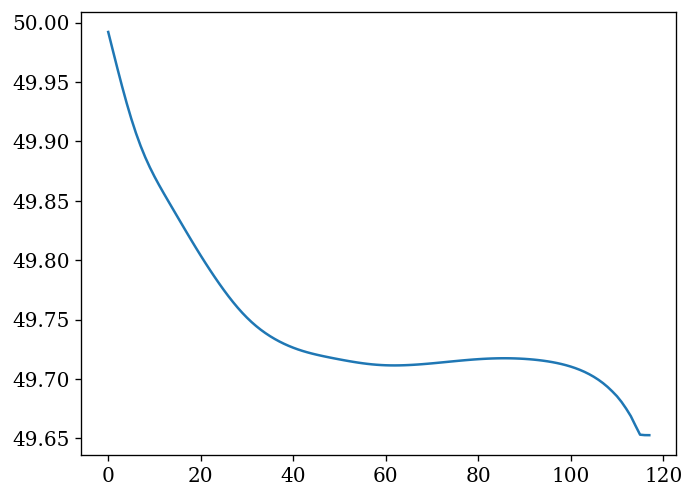

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 120

plotter = ss.TDS.plotter
time = np.asarray(plotter.get_values(0), dtype=float).reshape(-1)
f_coi = np.asarray(plotter.get_values(plotter.find("omega COI", idx_only=True)), dtype=float).reshape(-1) * 50
r_coi = np.gradient(f_coi, float(ss.TDS.config.tstep), axis=0)
# f_coi.shape
plt.plot(f_coi)
plt.show()

In [ ]:
ss.REGCV1.as_df().describe()

,u,bus,gen,Sn,fn,Tc,kw,kv,M,D,...,gammap,gammaq,Kpvd,Kivd,Kpvq,Kivq,KpId,KiId,KpIq,KiIq
count,4.0,4.000000,4.000000,4.00000,4.0,4.00,4.0,4.0,4.000000,4.000000,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
mean,1.0,35.000000,6.000000,1195.00000,50.0,0.01,0.0,0.0,82.221345,48.291694,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0,3.559026,3.559026,329.50738,0.0,0.00,0.0,0.0,28.519124,31.714122,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,1.0,30.000000,1.000000,970.20000,50.0,0.01,0.0,0.0,47.649032,5.876667,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,1.0,33.750000,4.750000,1022.55000,50.0,0.01,0.0,0.0,72.280830,34.699765,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,1.0,36.000000,7.000000,1062.85000,50.0,0.01,0.0,0.0,81.896300,53.930728,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,1.0,37.250000,8.250000,1235.30000,50.0,0.01,0.0,0.0,91.836815,67.522657,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,38.000000,9.000000,1684.10000,50.0,0.01,0.0,0.0,117.443750,79.428654,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


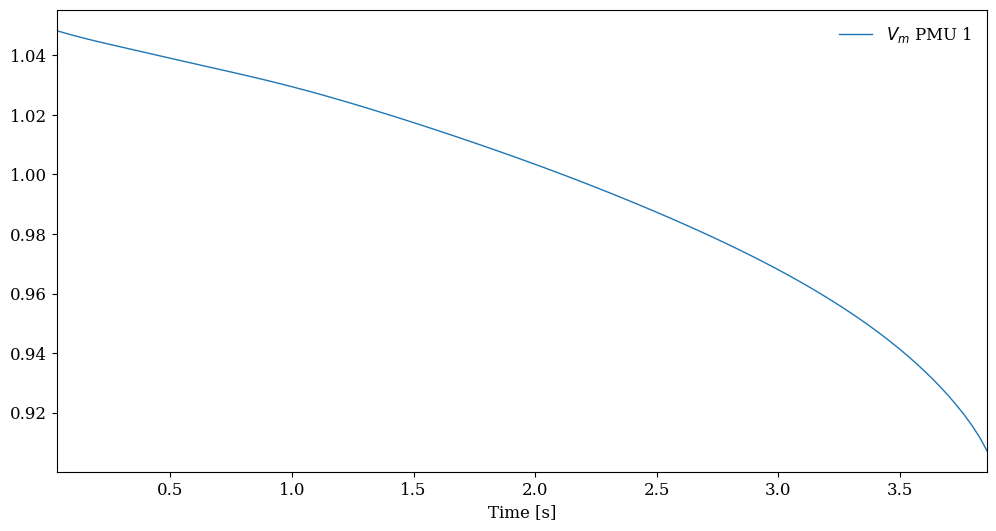

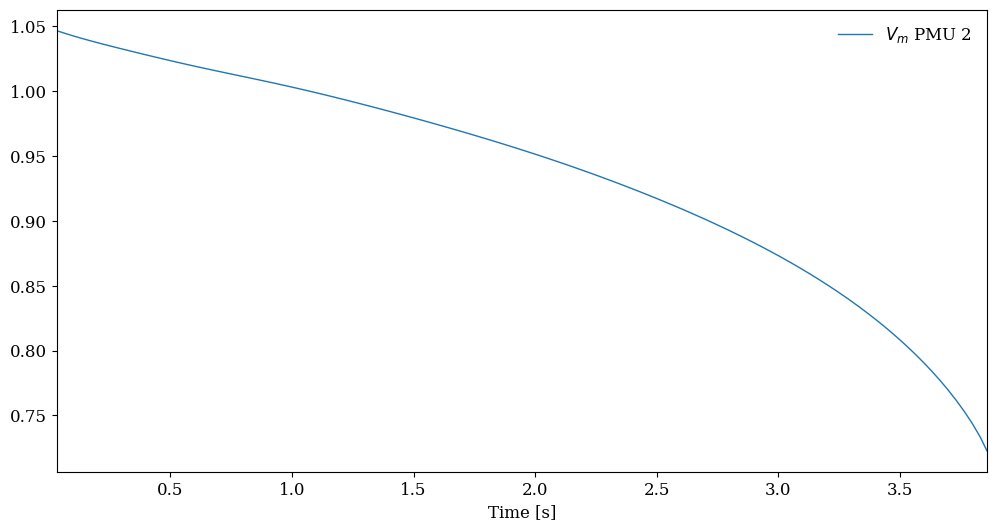

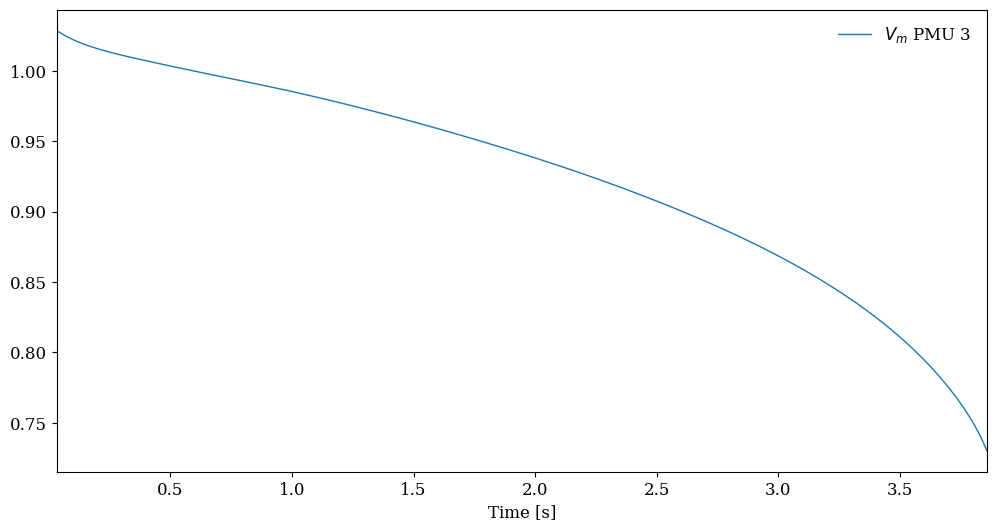

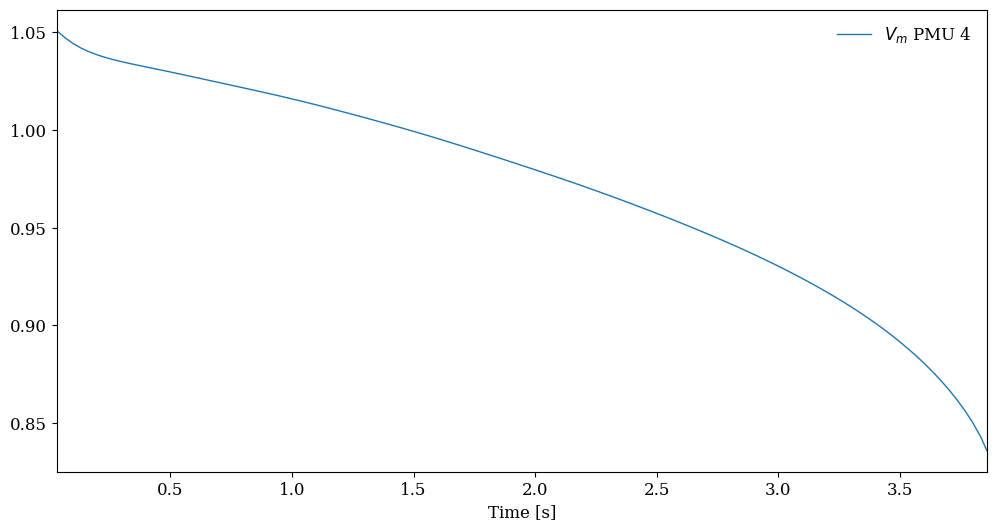

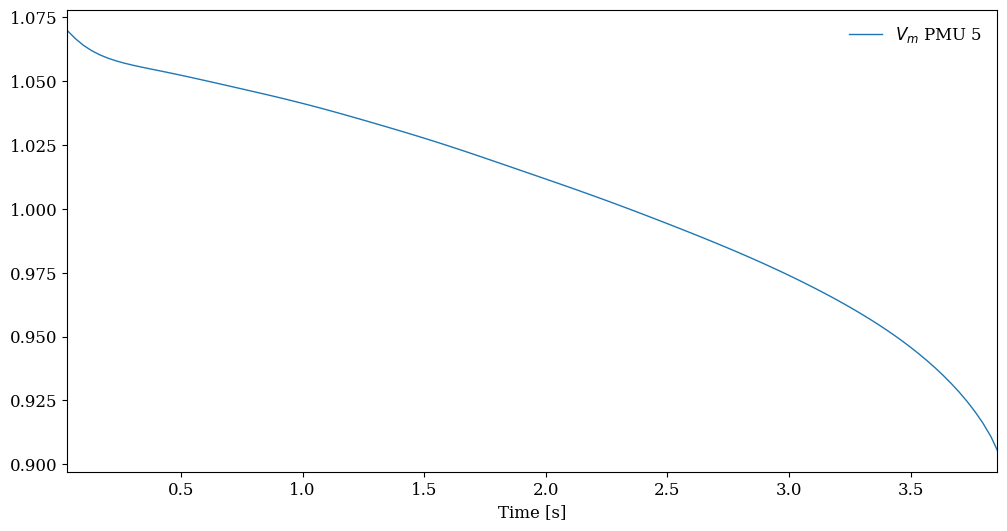

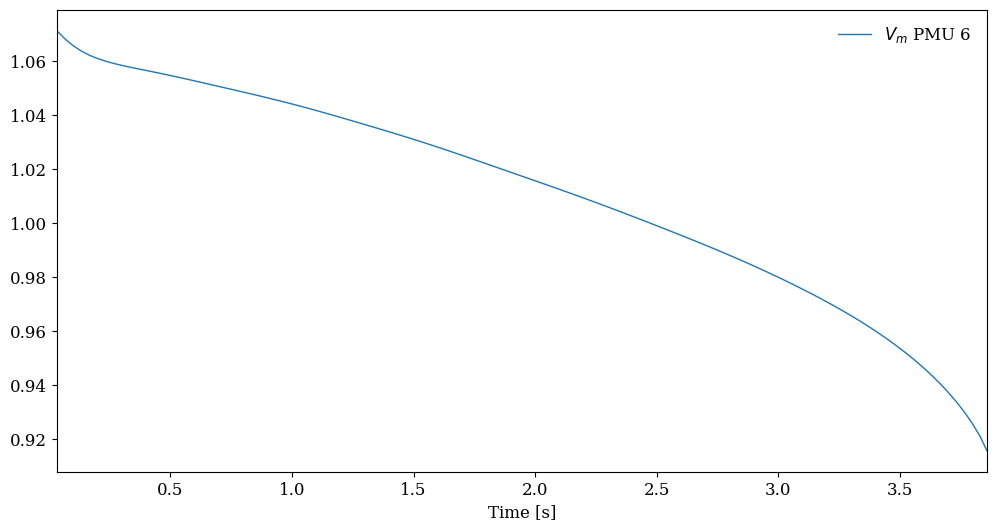

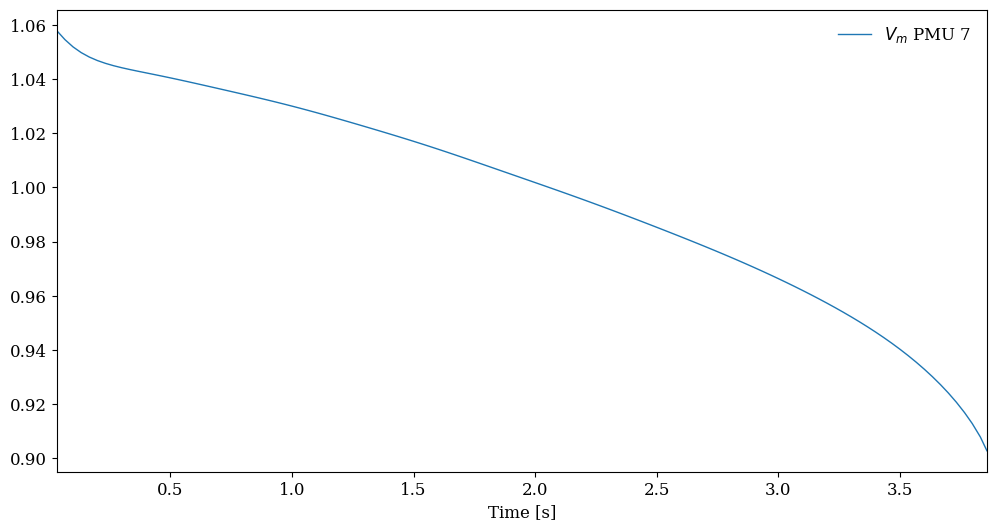

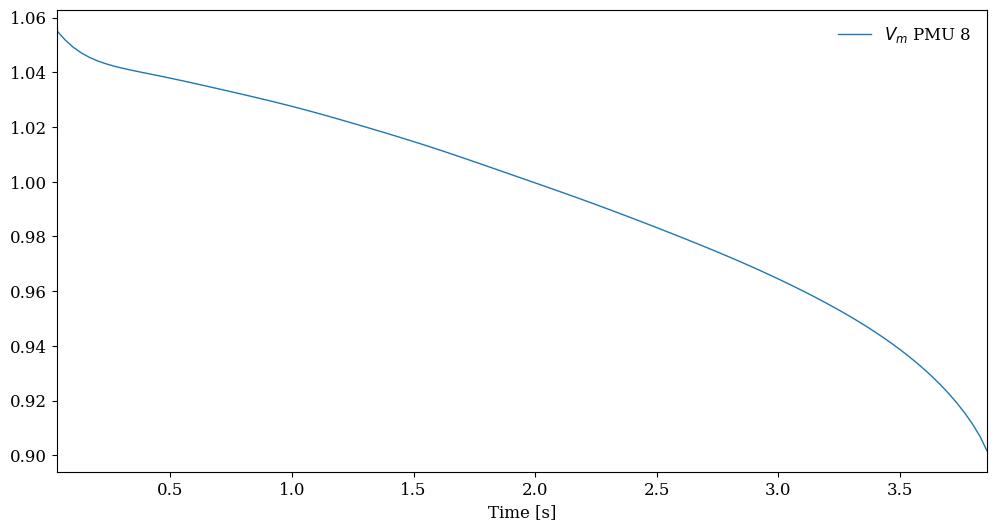

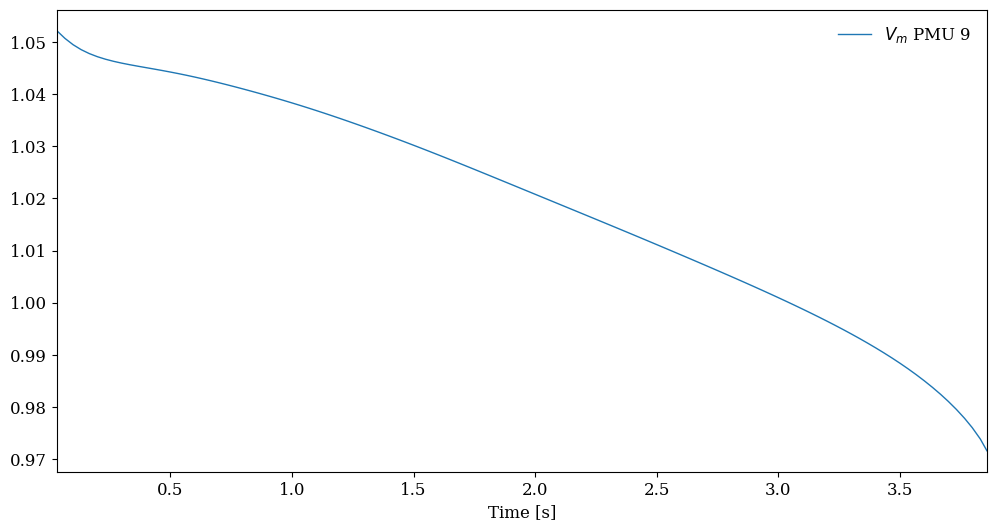

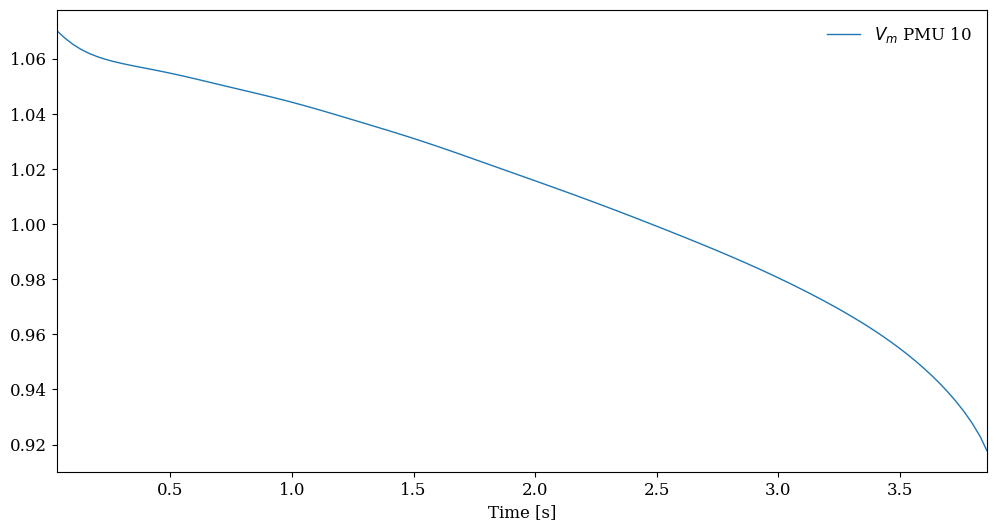

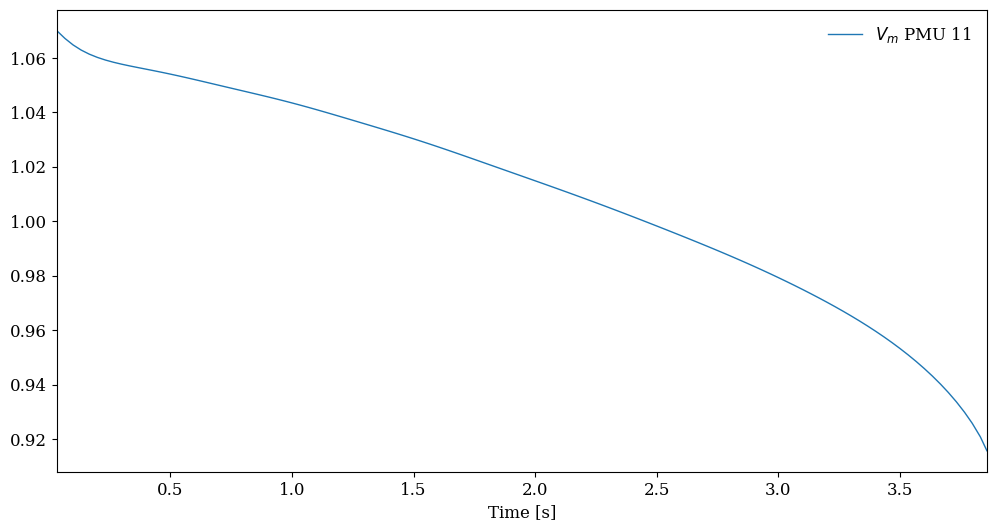

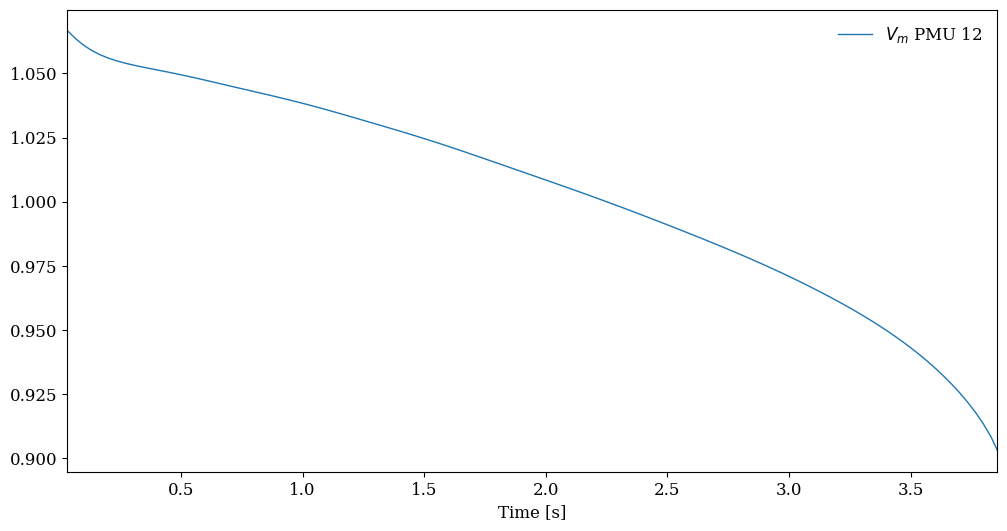

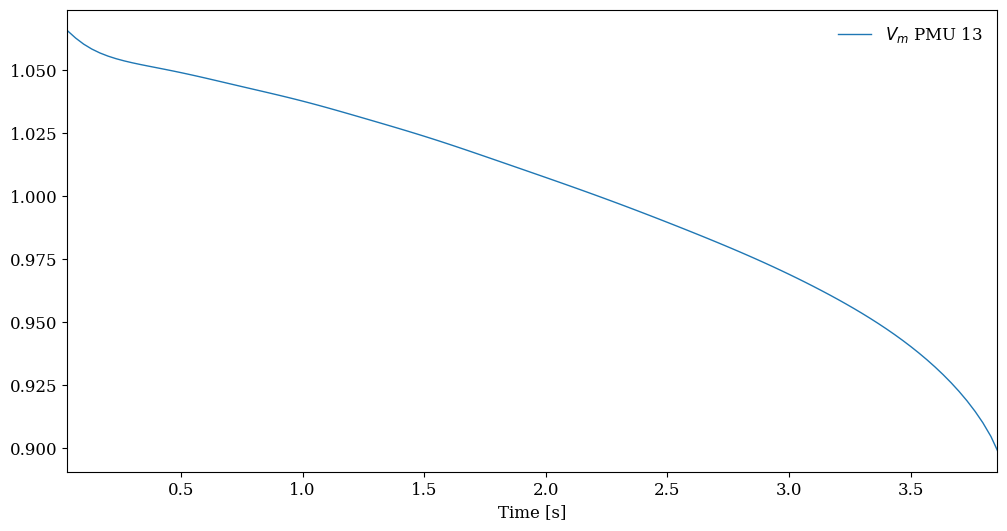

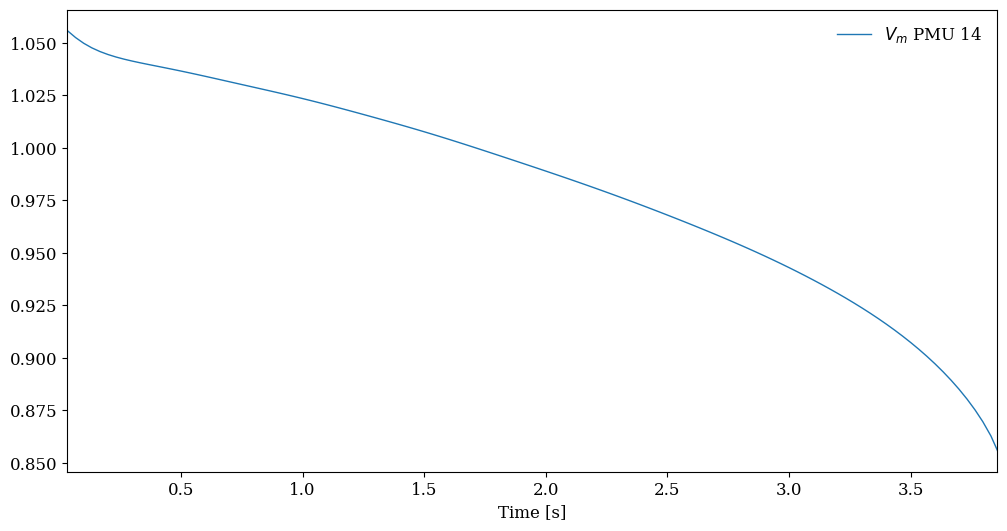

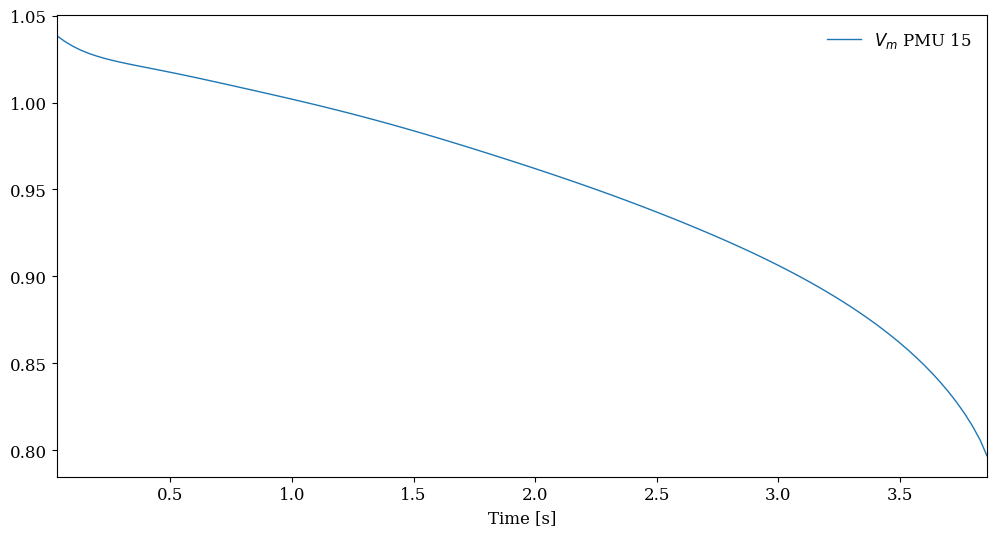

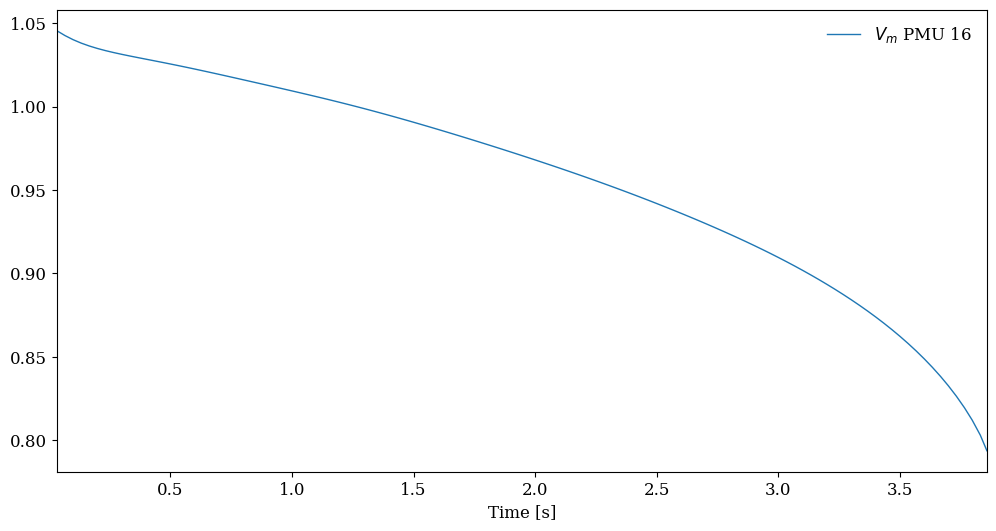

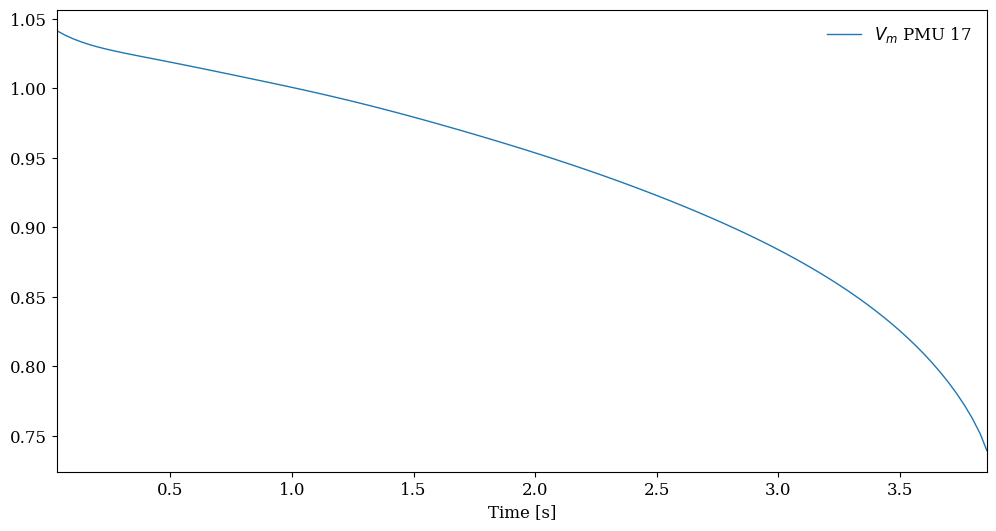

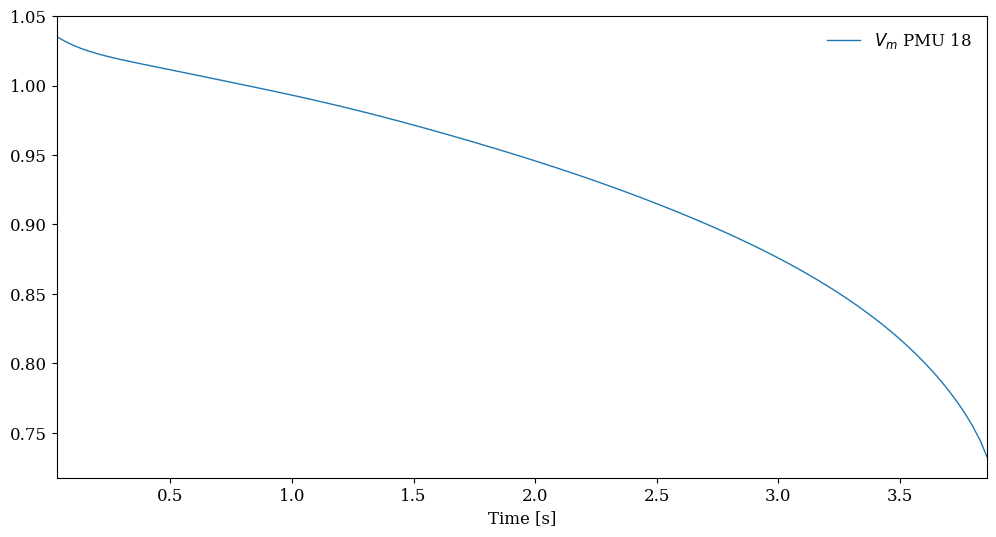

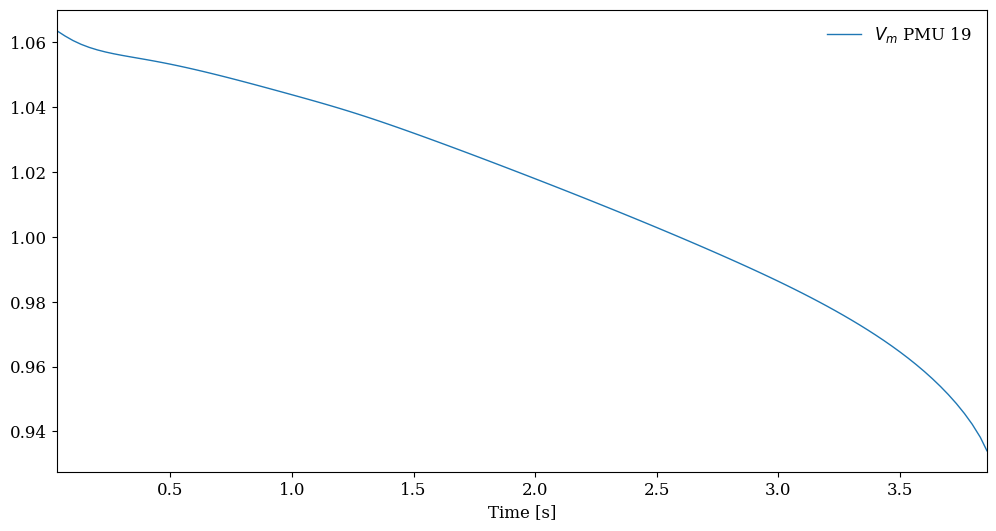

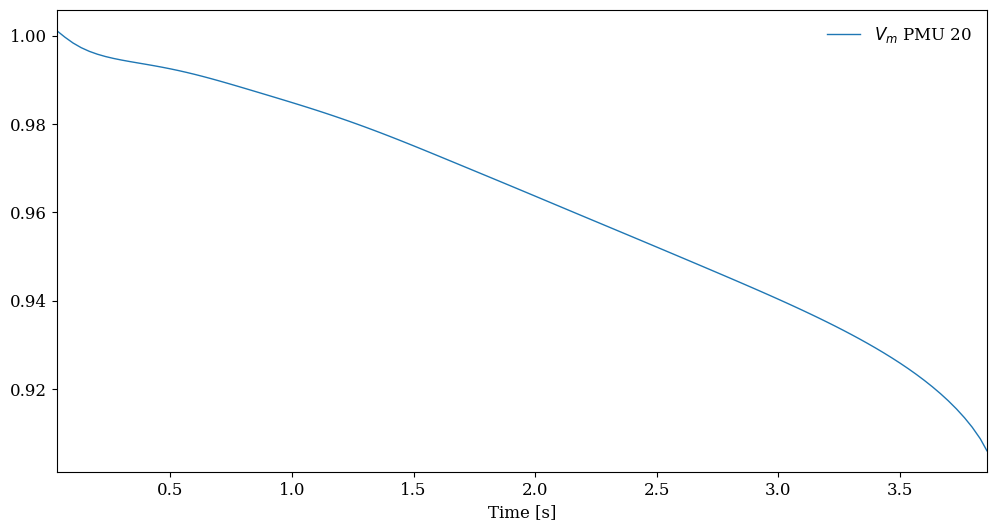

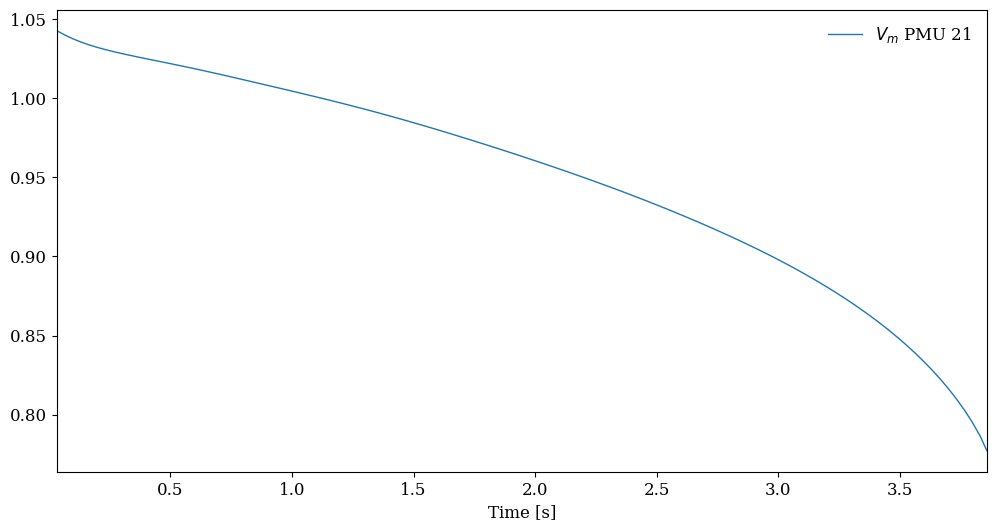

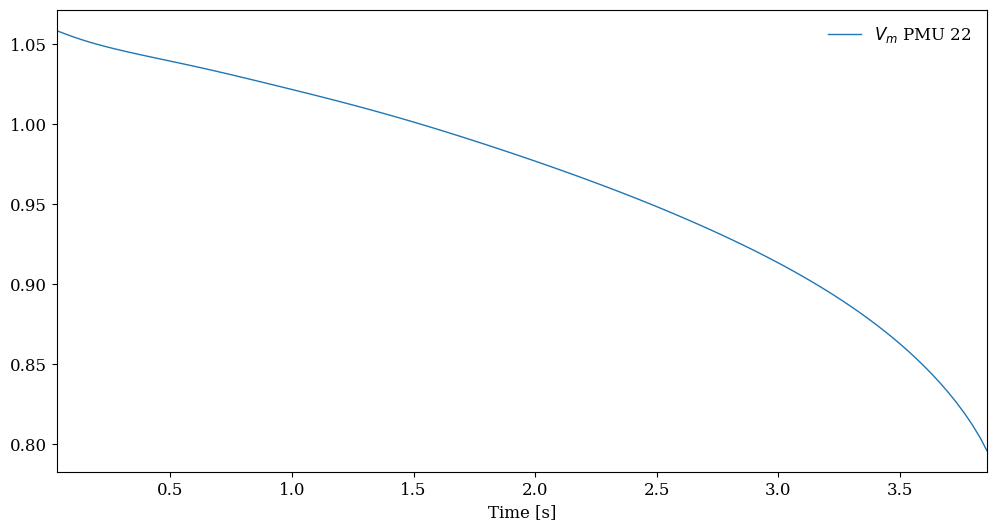

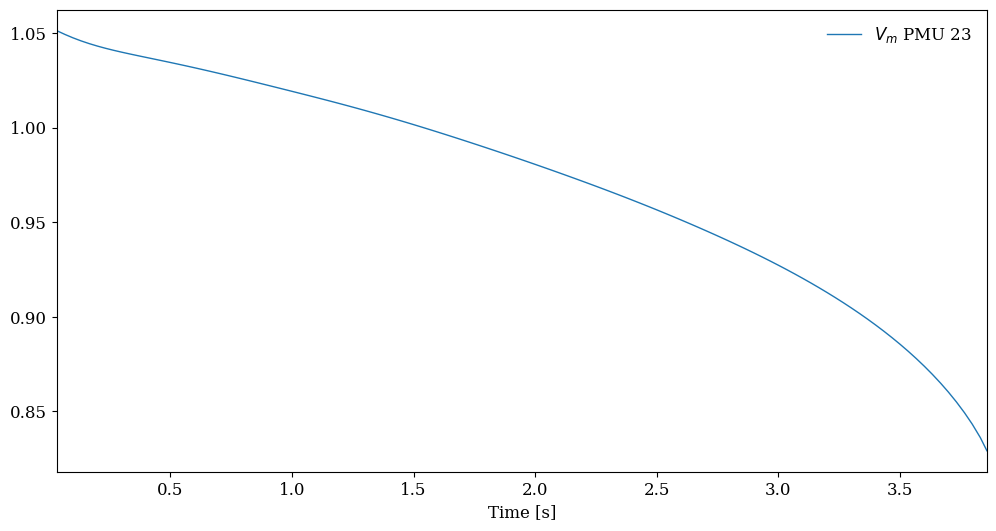

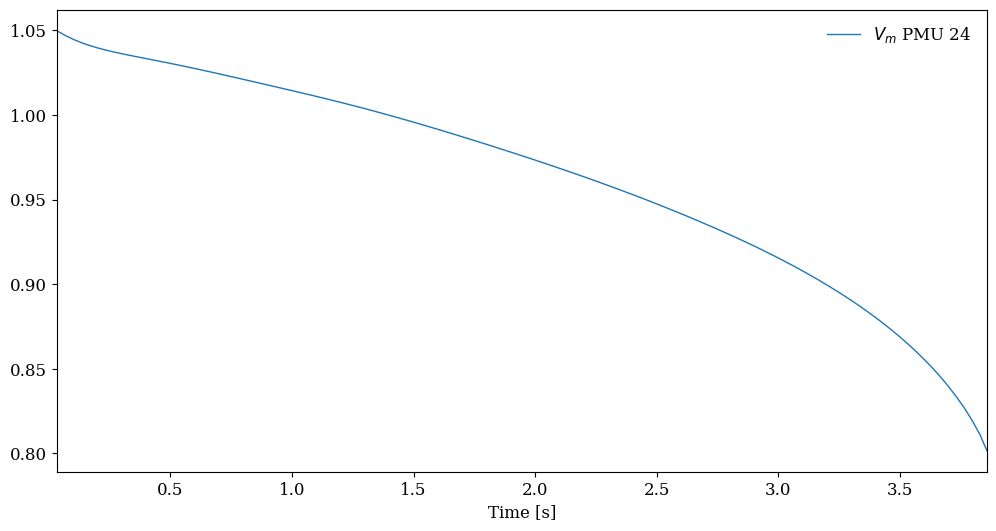

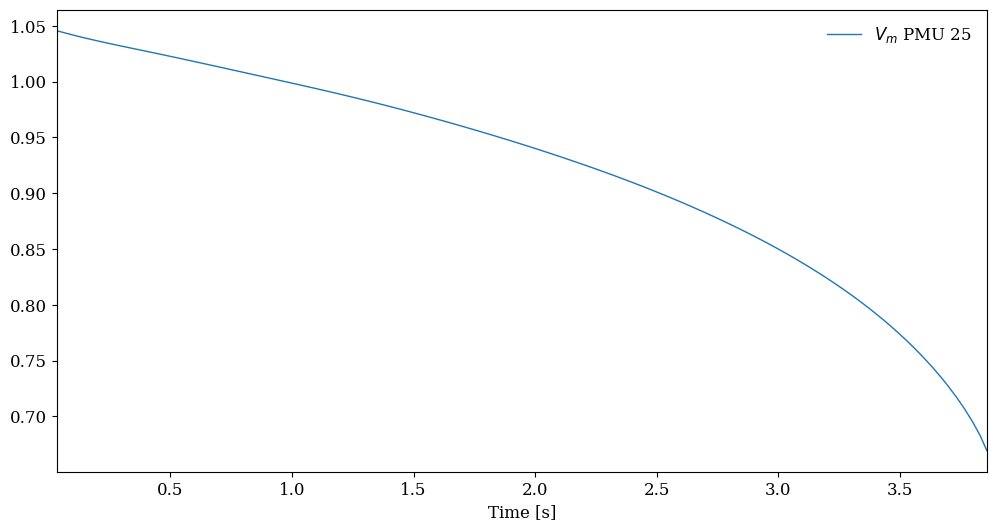

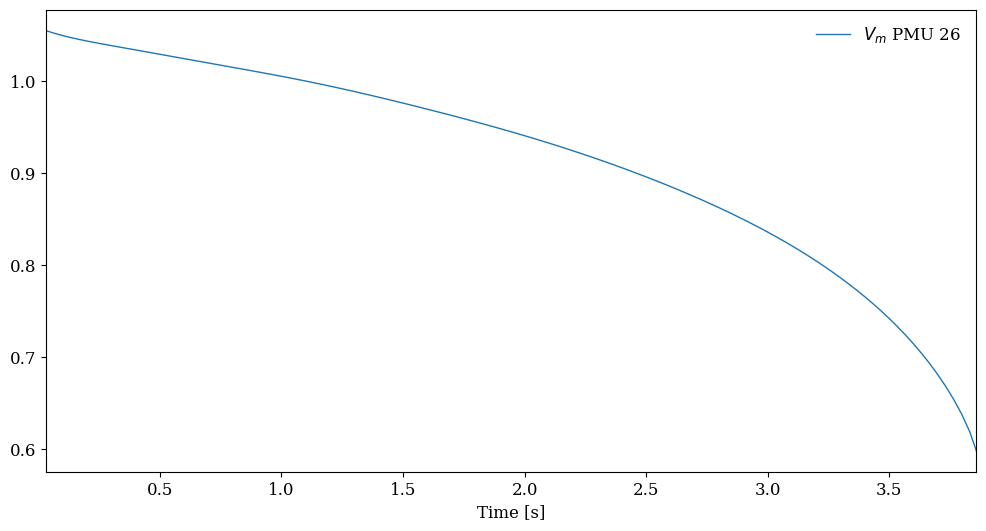

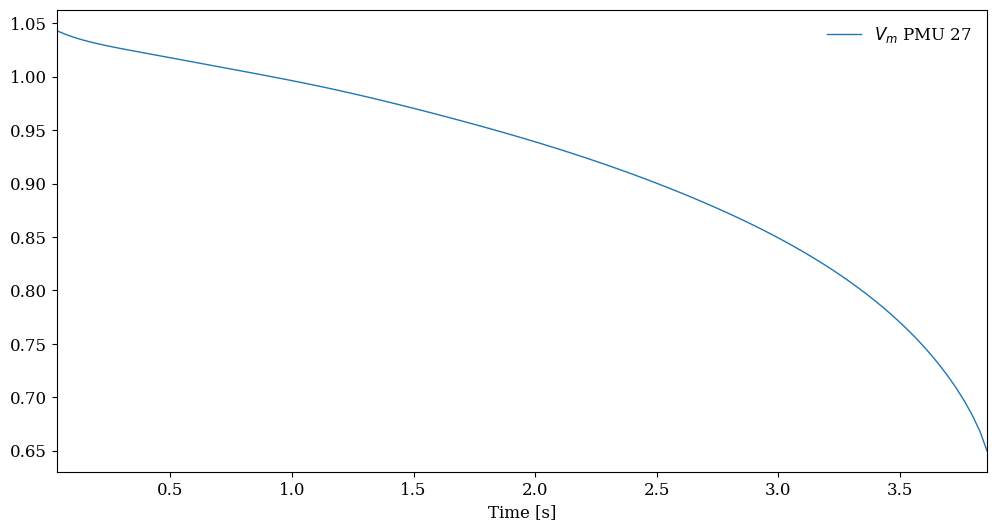

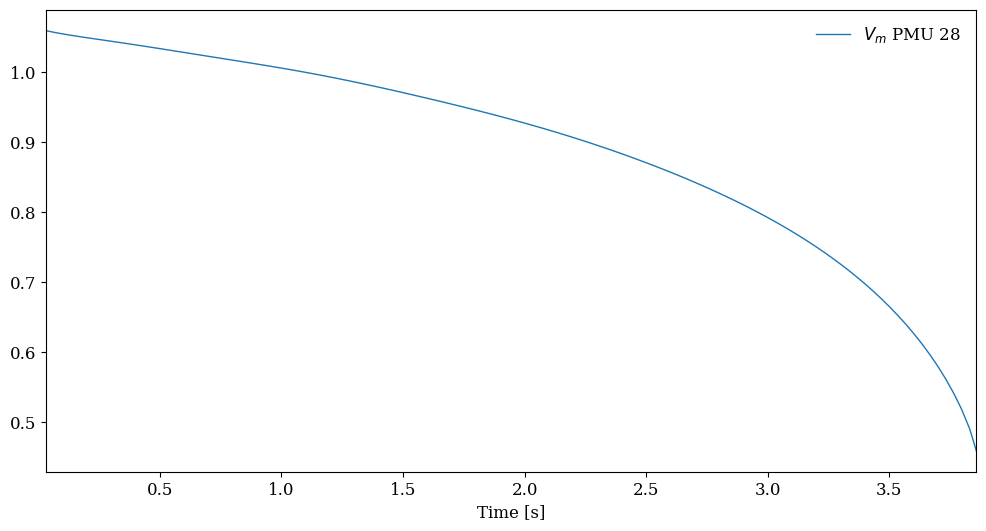

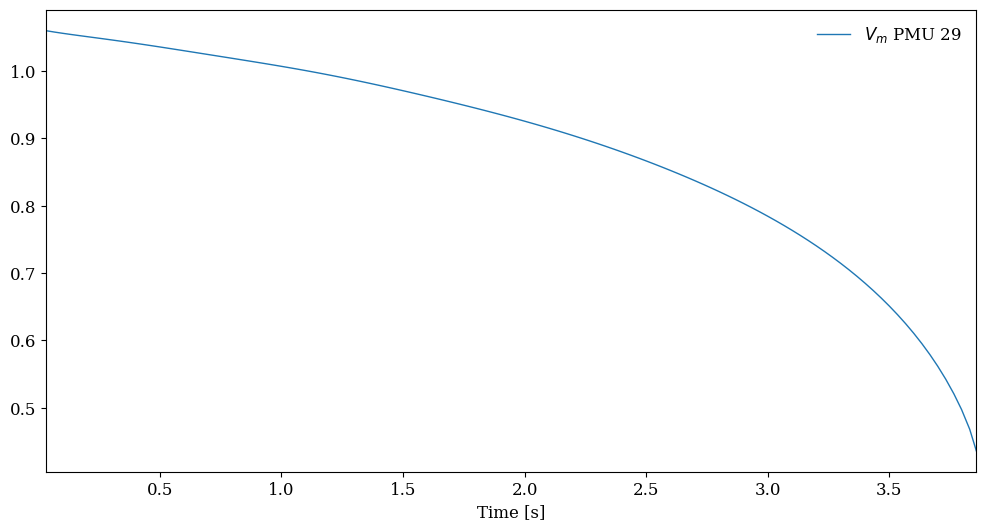

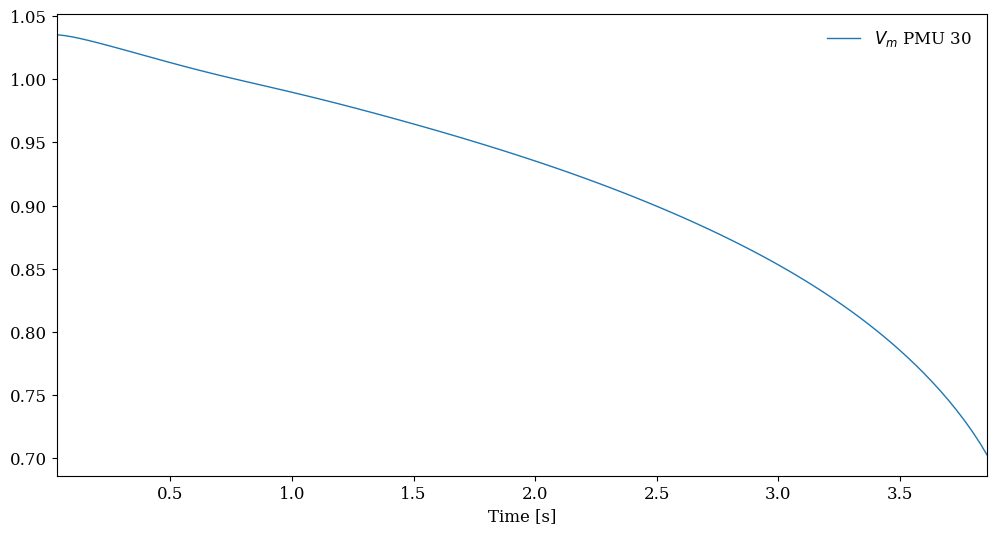

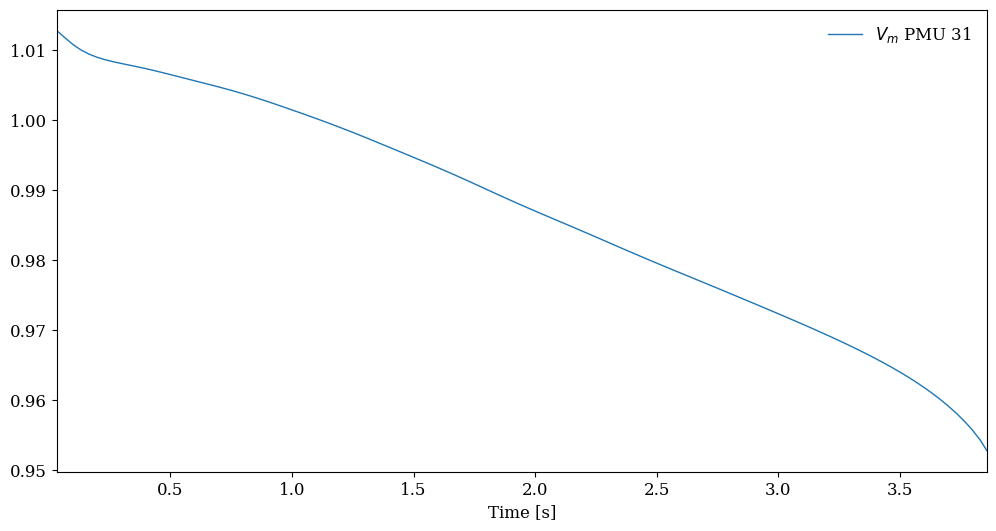

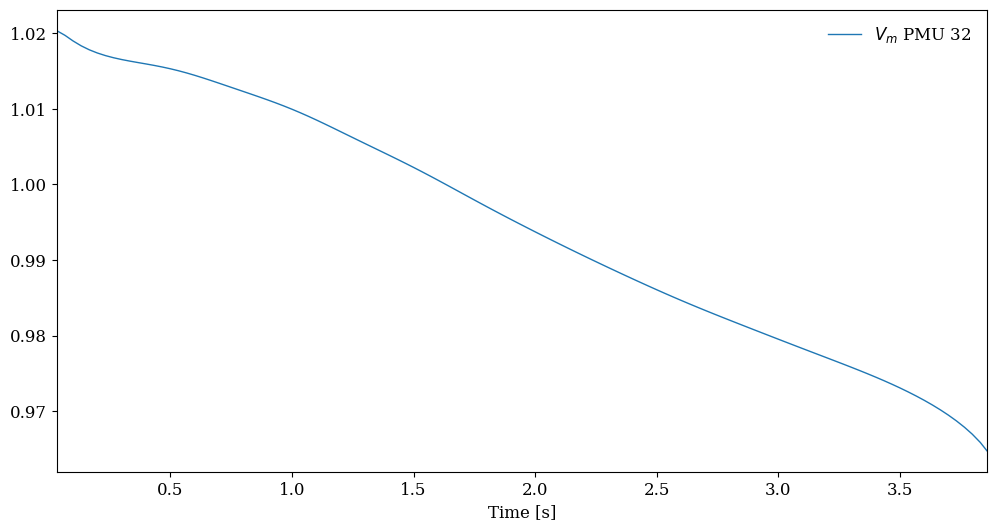

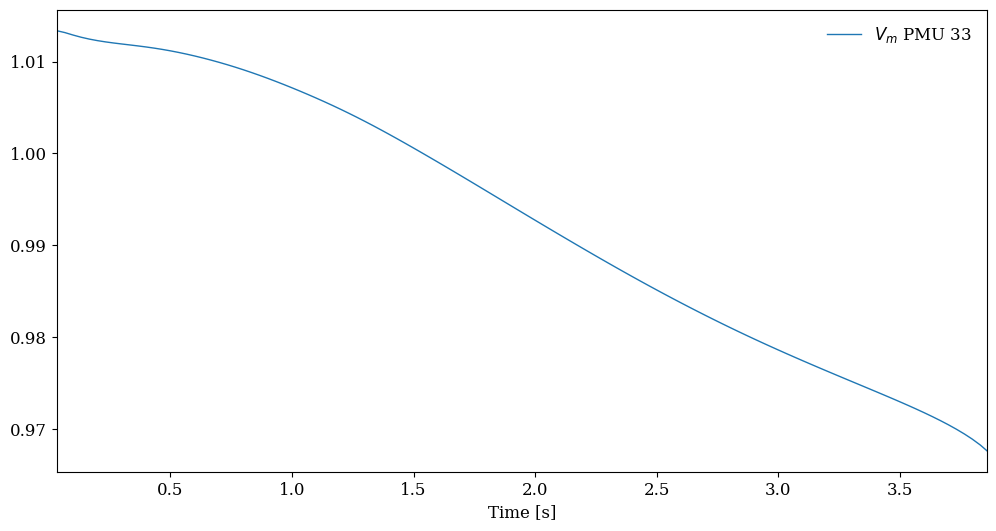

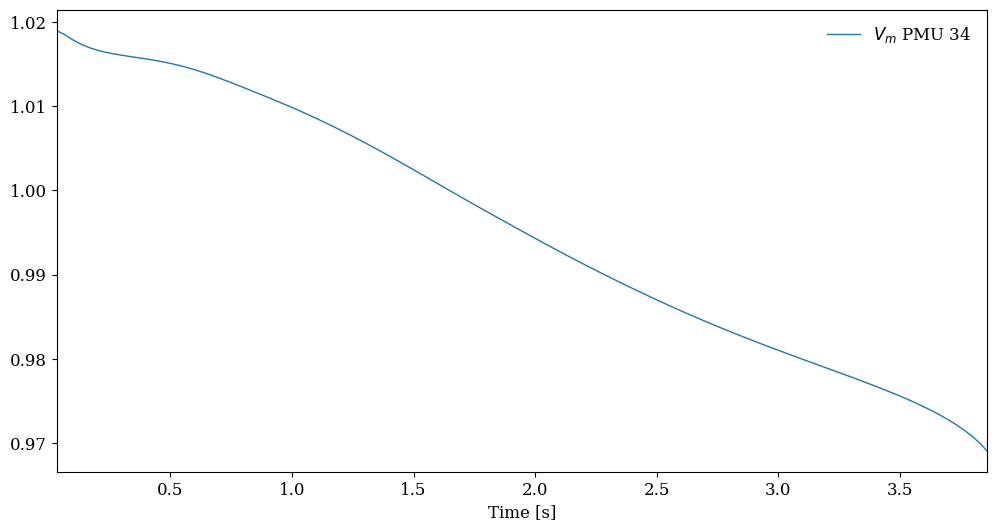

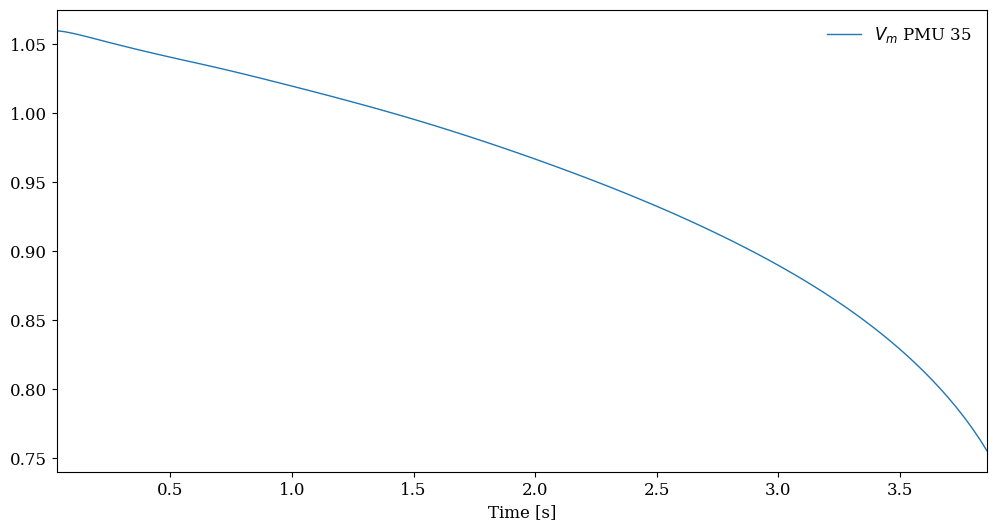

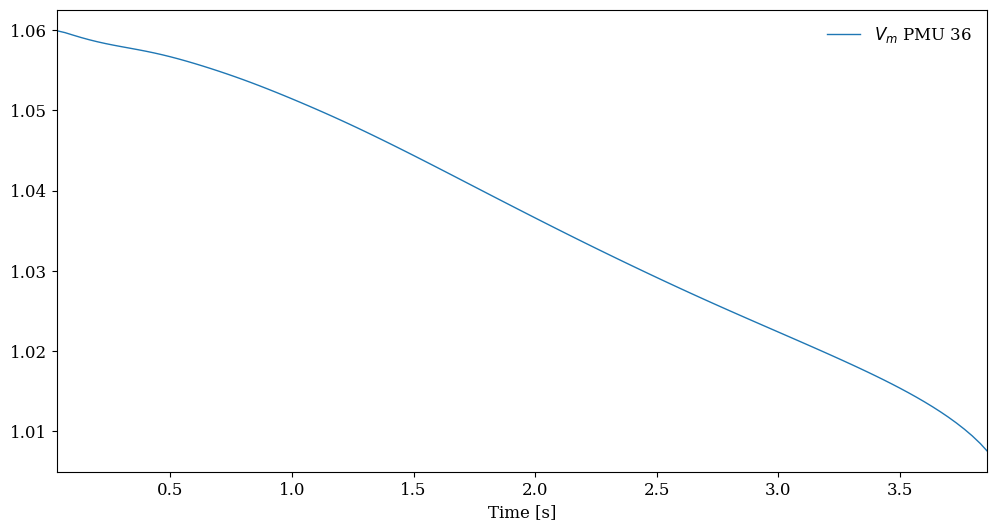

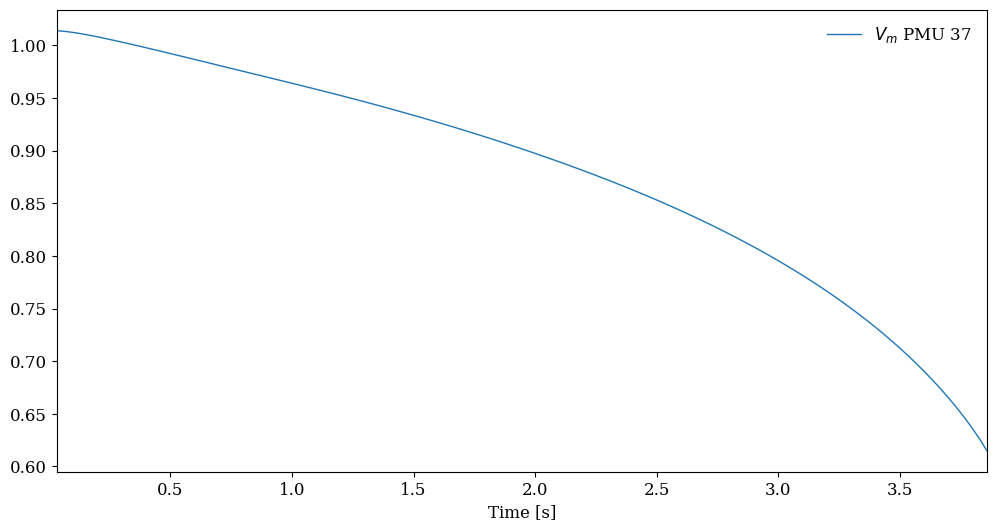

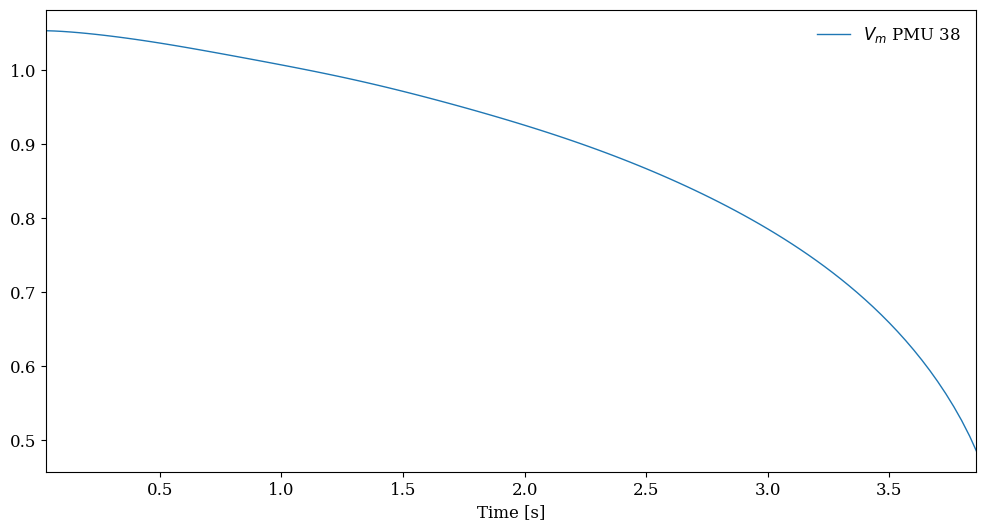

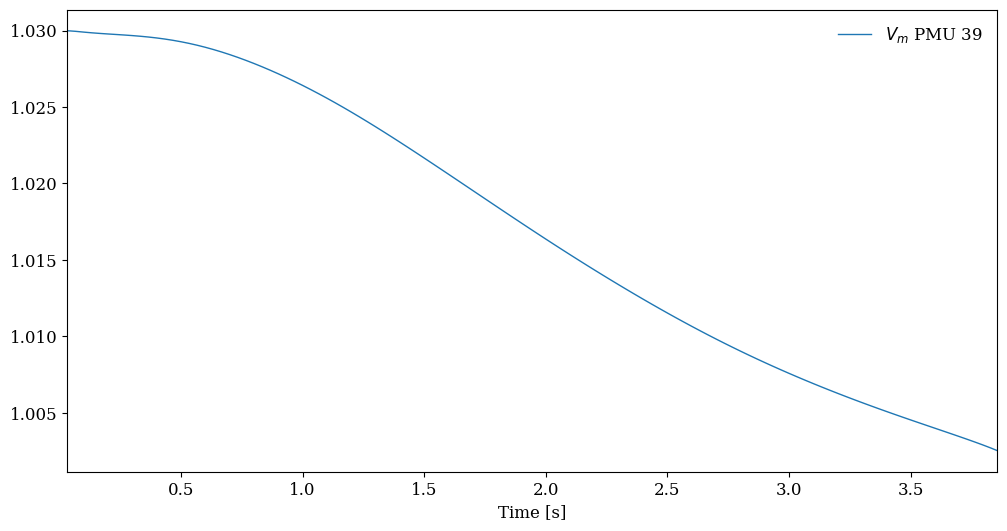

In [ ]:
indices = ss.TDS.plotter.find("vm PMU", idx_only=True)
for i in indices: 
    ss.TDS.plotter.plot(i, figsize=(12, 6))

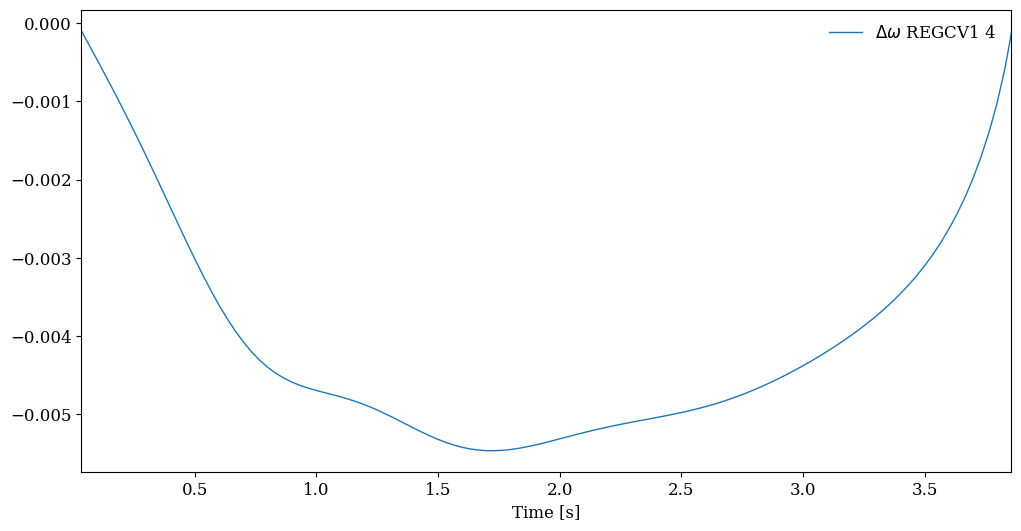

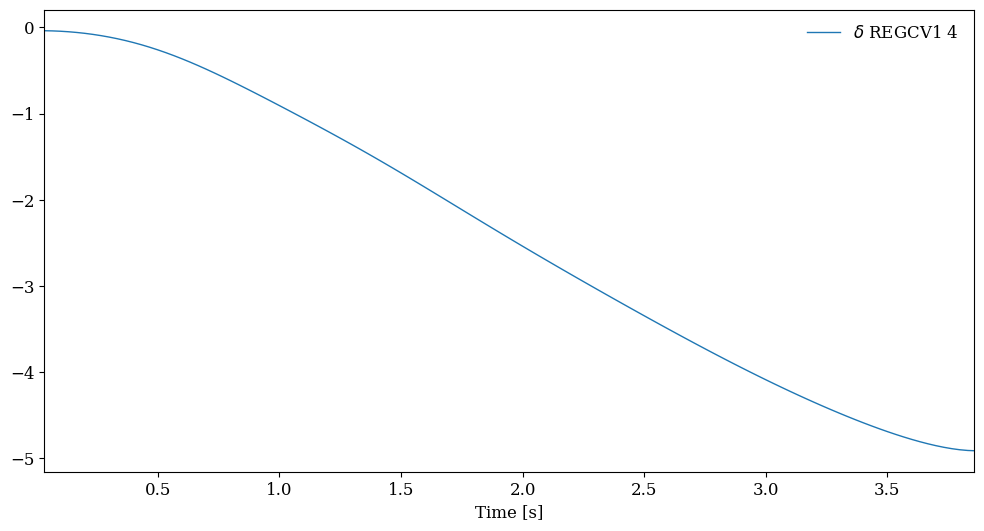

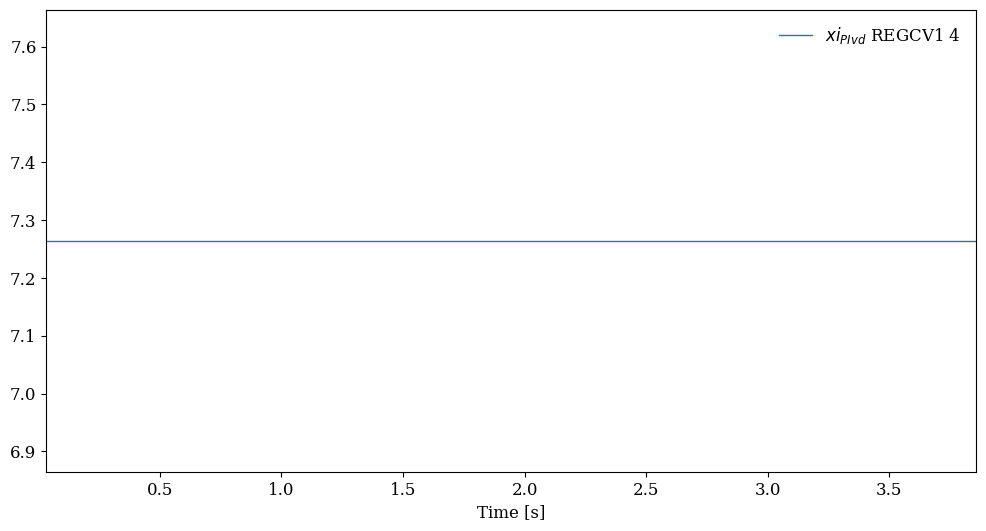

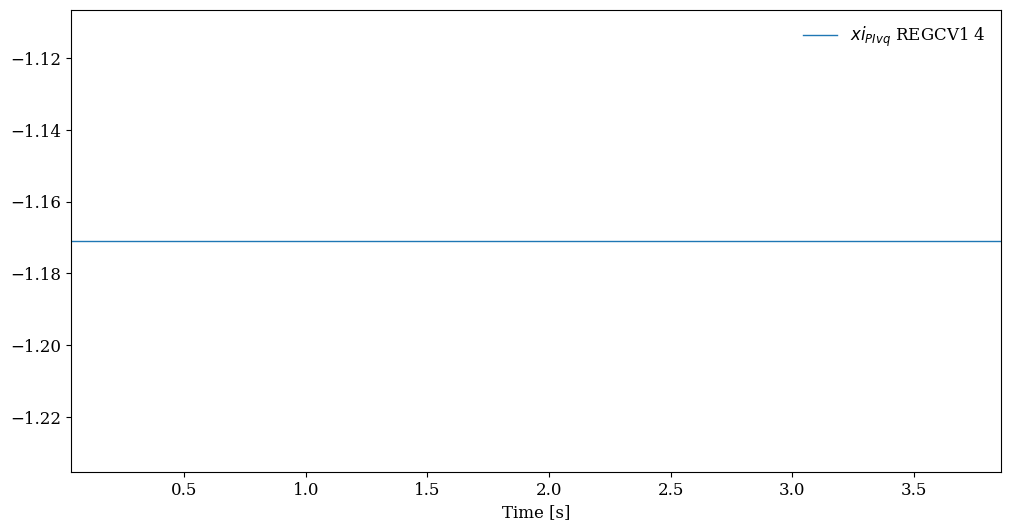

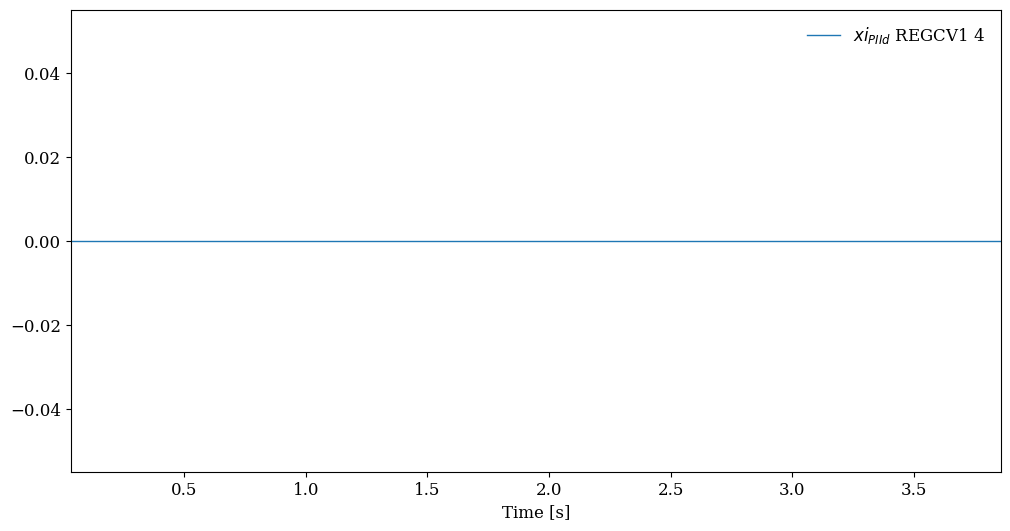

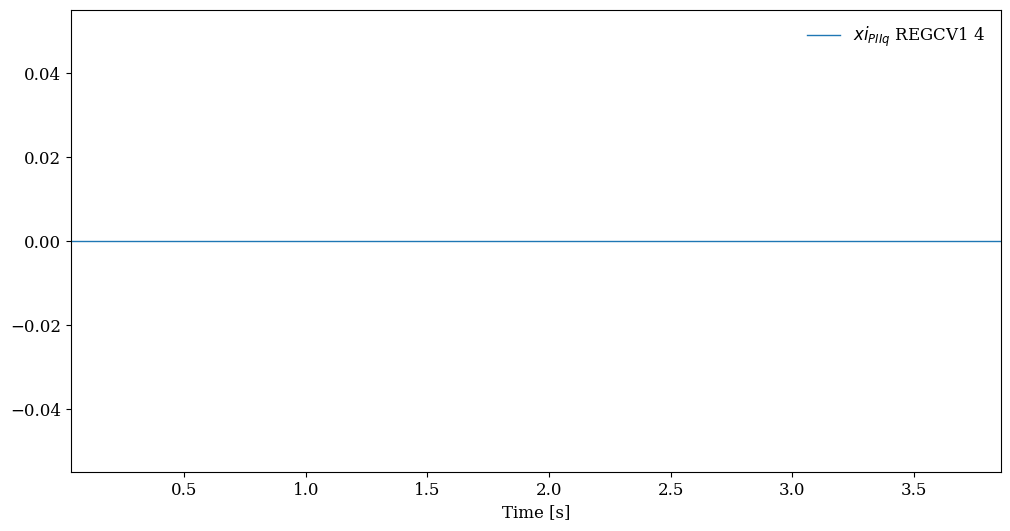

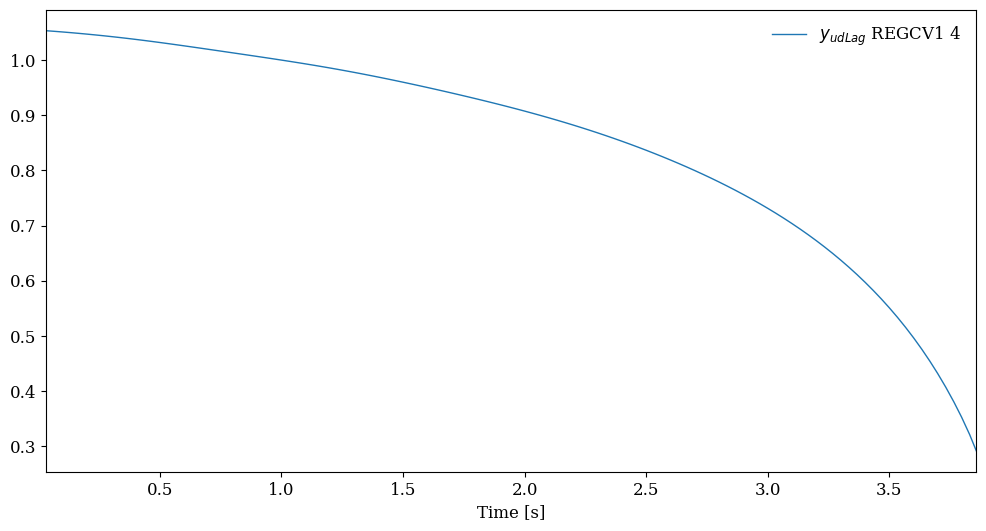

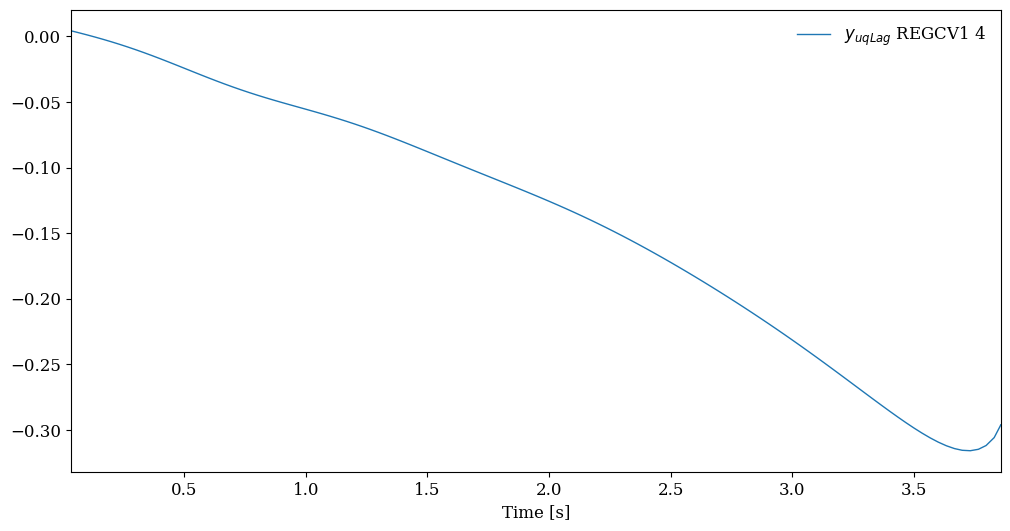

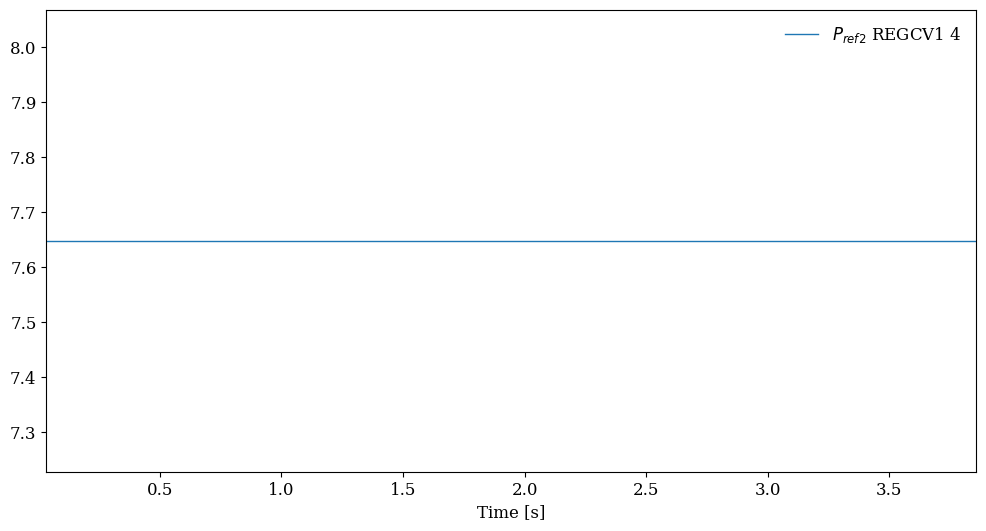

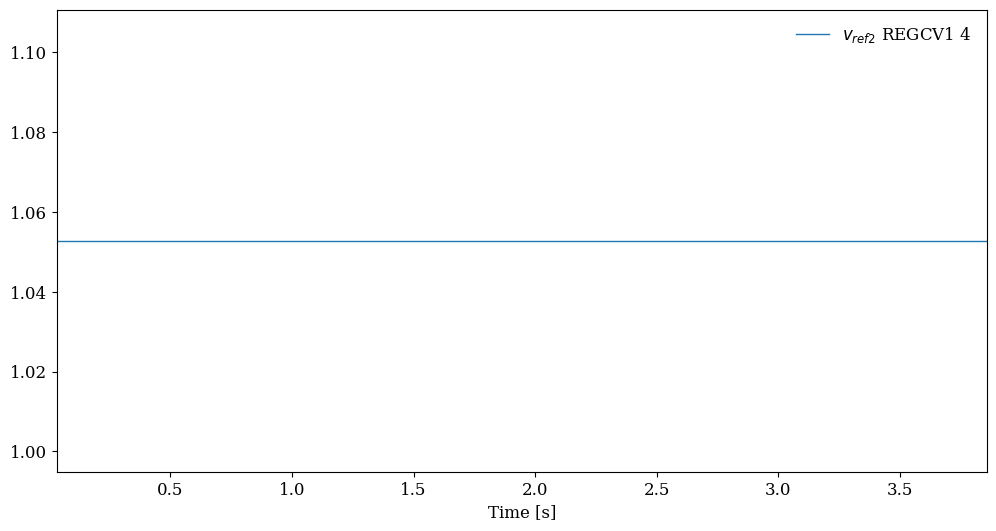

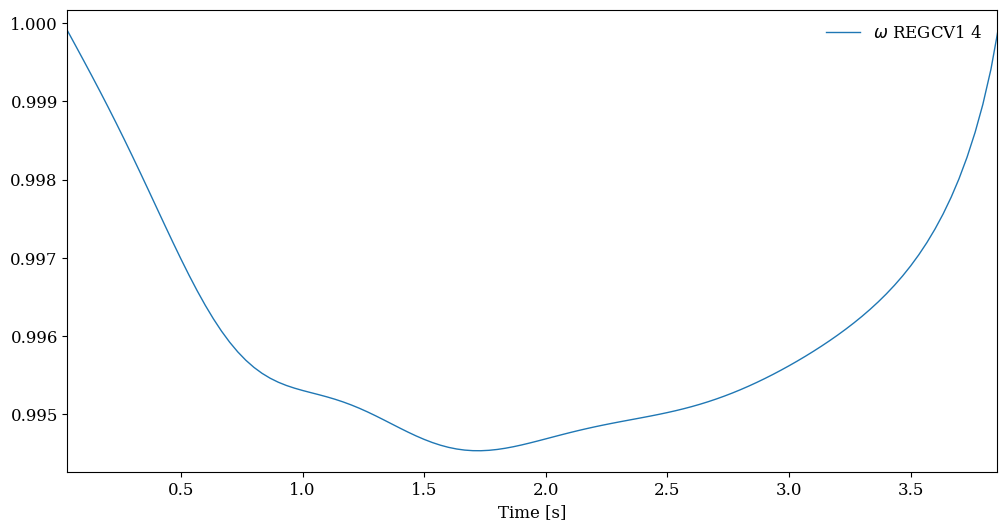

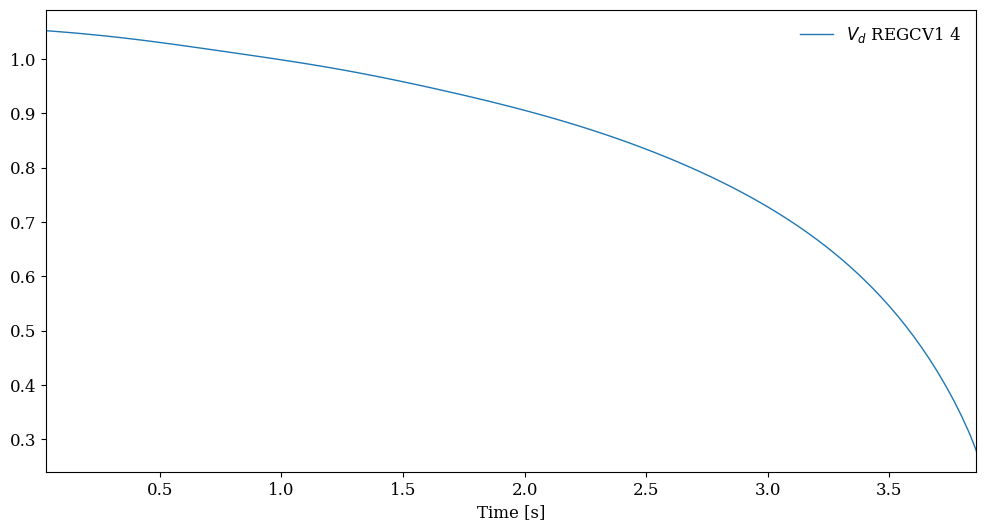

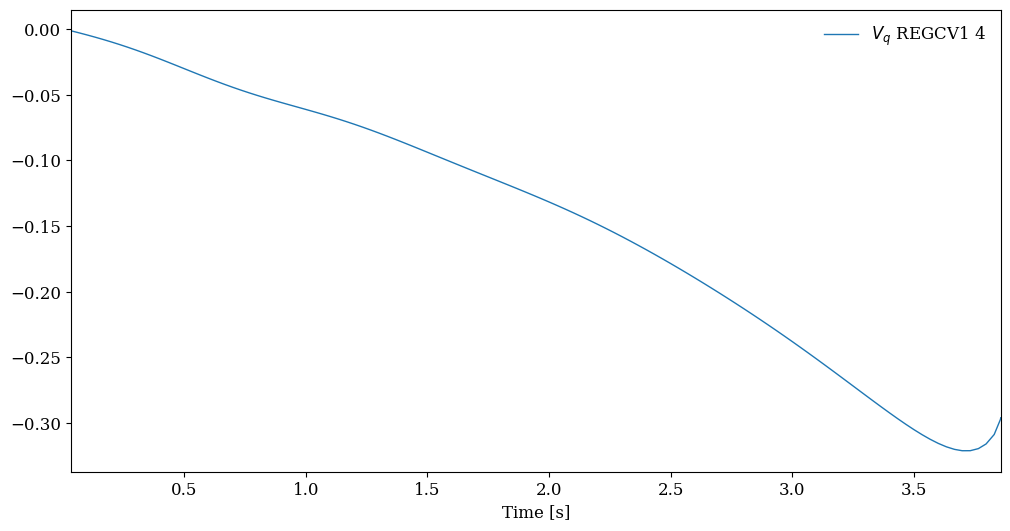

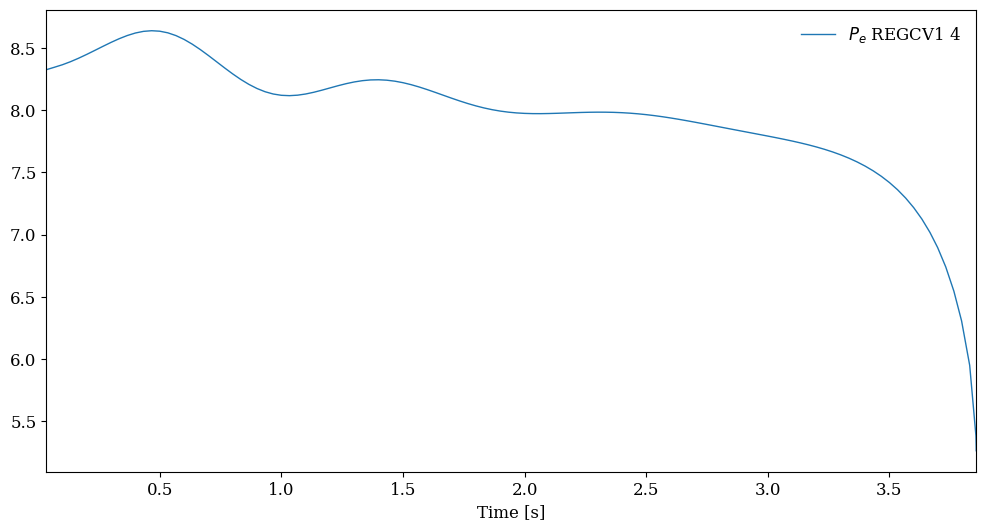

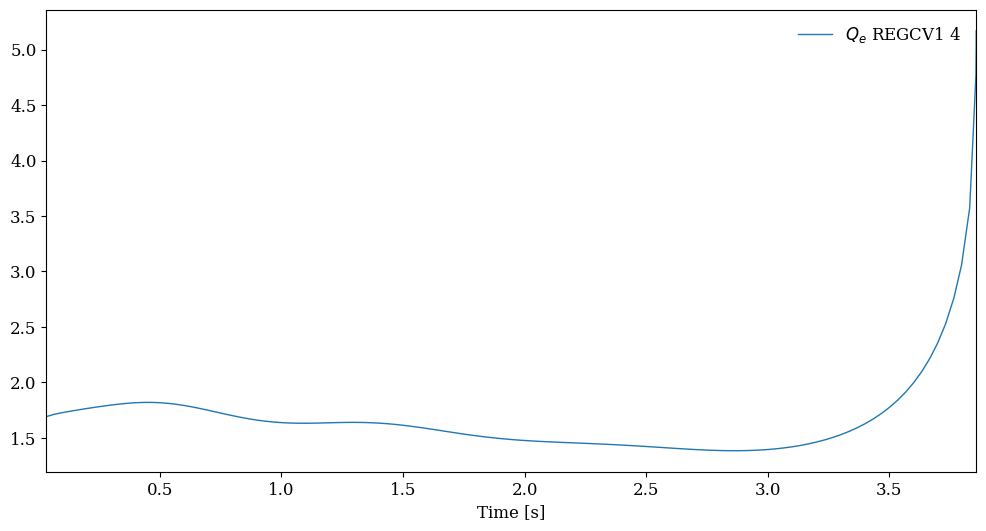

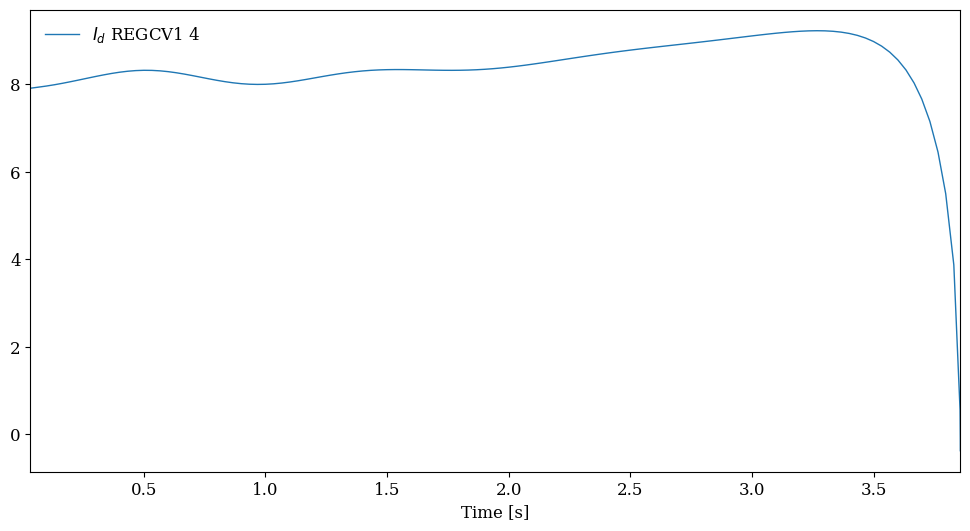

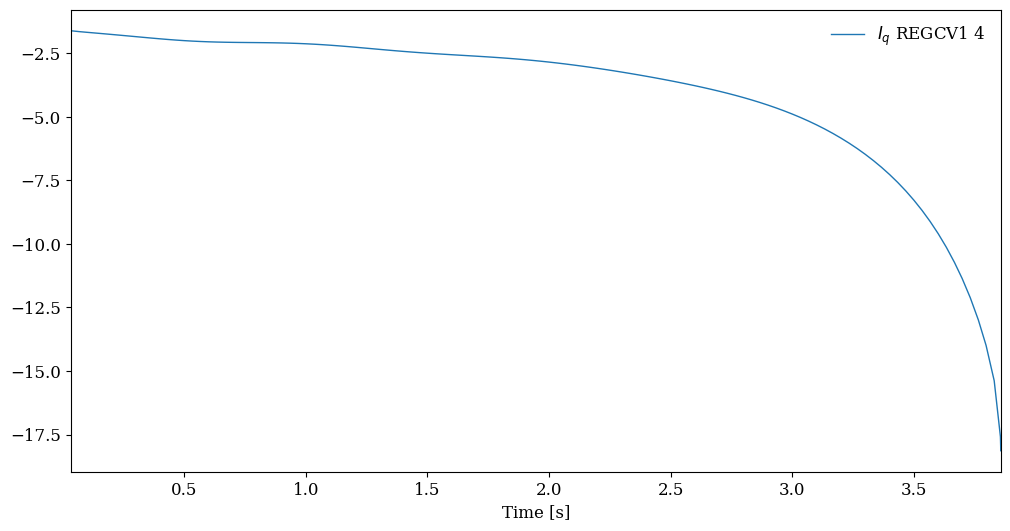

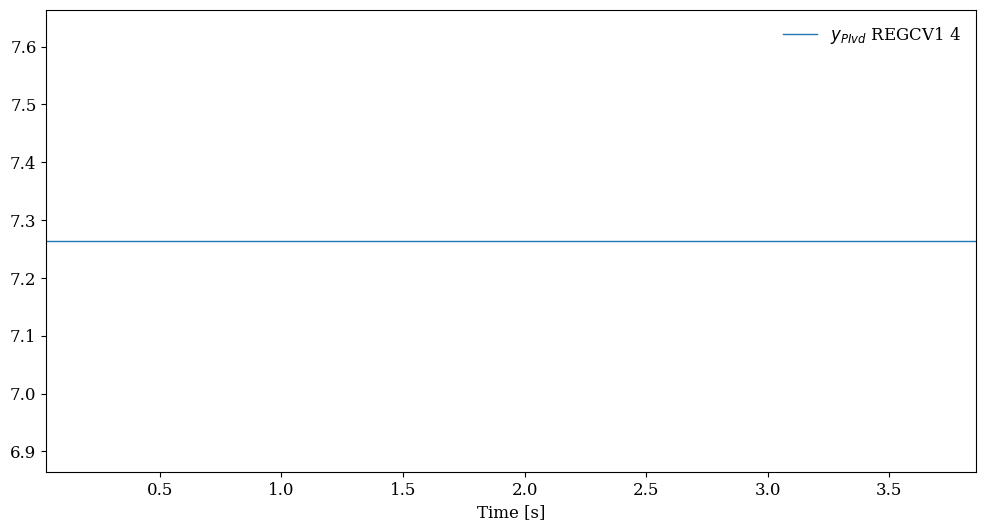

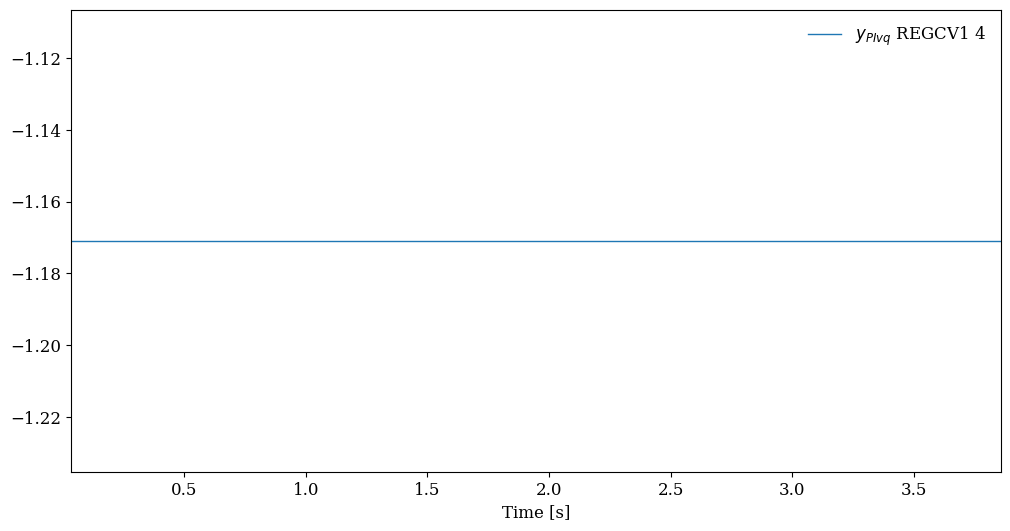

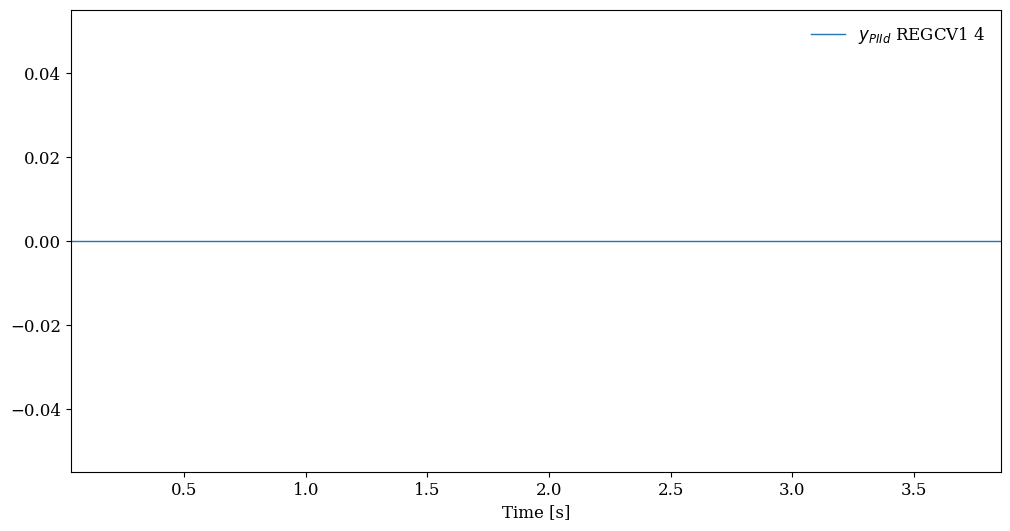

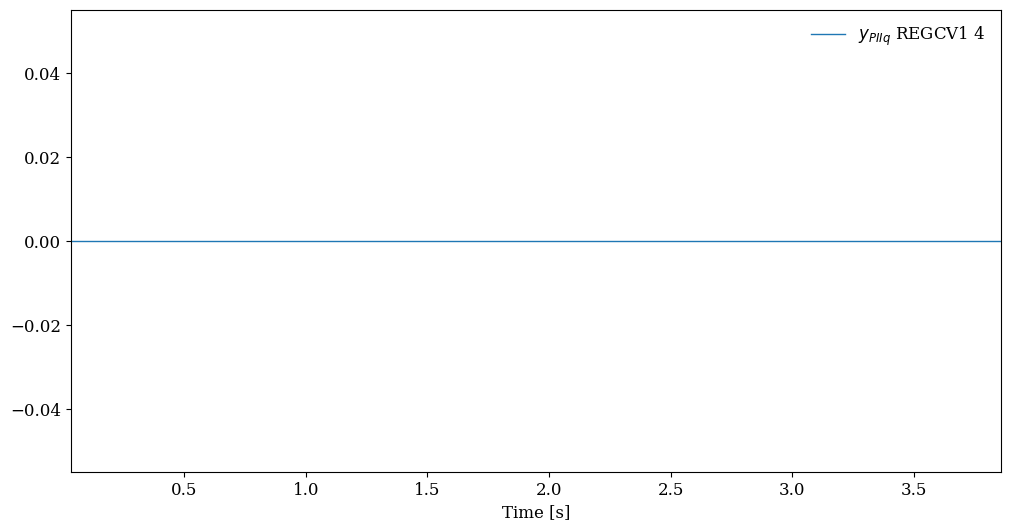

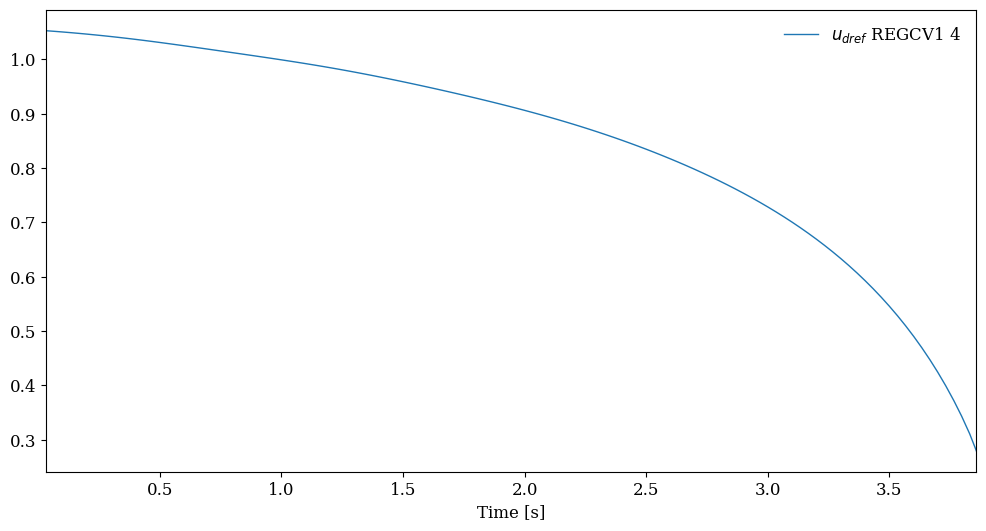

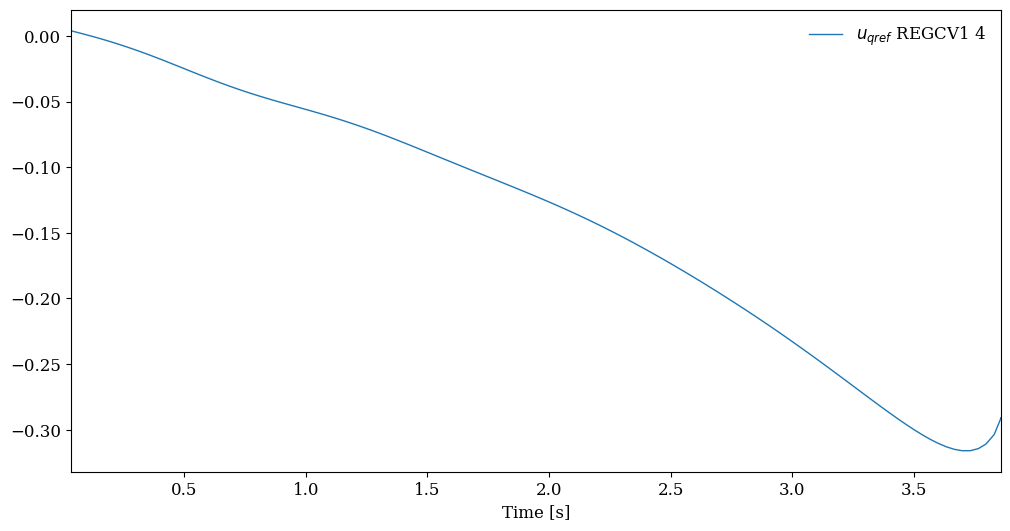

In [ ]:
indices = ss.TDS.plotter.find("REGCV1 4", idx_only=True)
for i in indices: 
    ss.TDS.plotter.plot(i, figsize=(12, 6))#, bbox=(1,1))

In [ ]:
ss.REGCV1.KpId

NumParam: REGCV1.KpId, v=[0. 0. 0. 0.], vin=[0. 0. 0. 0.]

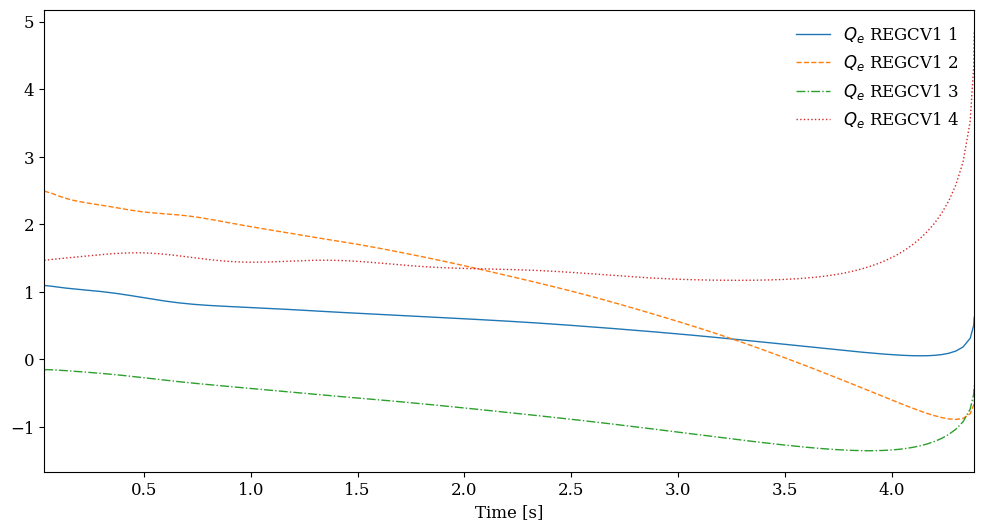

(<Figure size 1200x600 with 1 Axes>, <Axes: xlabel='Time [s]'>)

In [ ]:
ss.TDS.plotter.plot(ss.TDS.plotter.find("Qe REGCV1", idx_only=True), figsize=(12, 6))

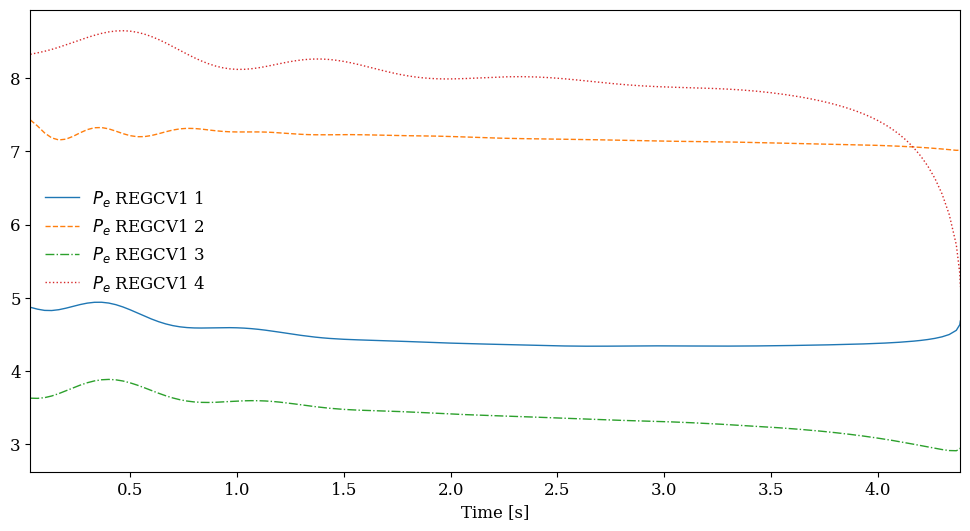

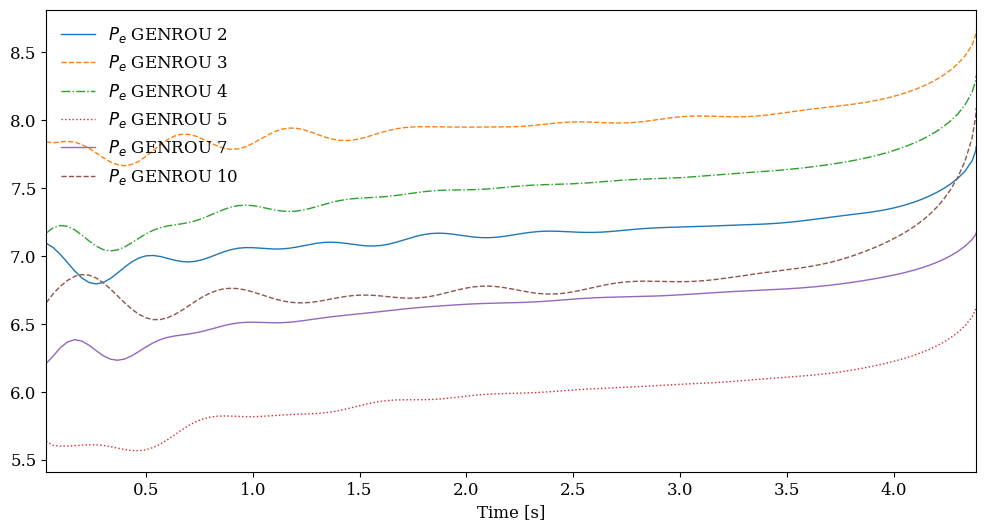

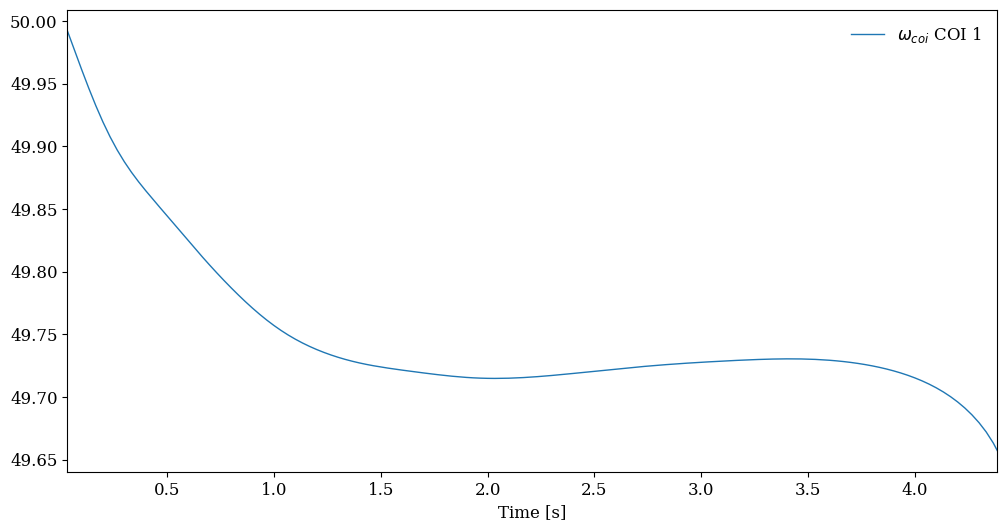

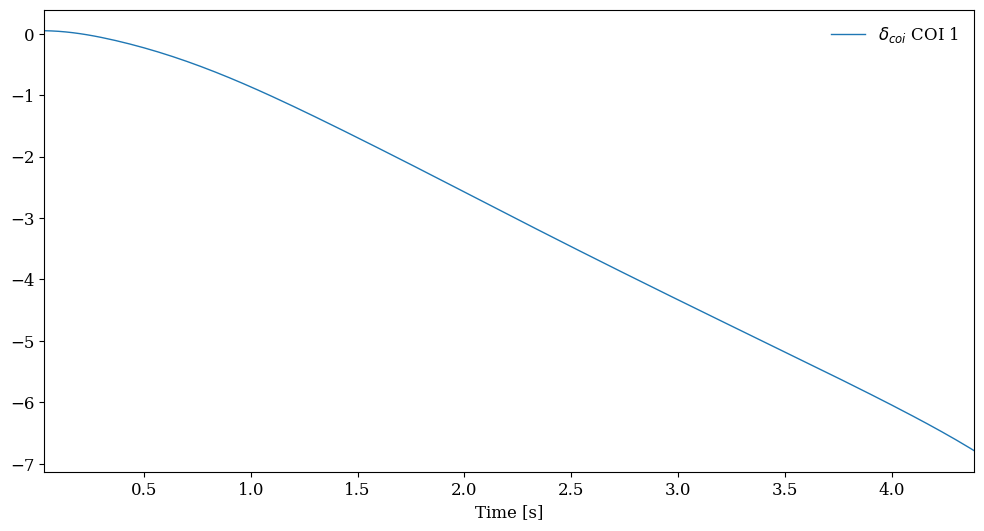

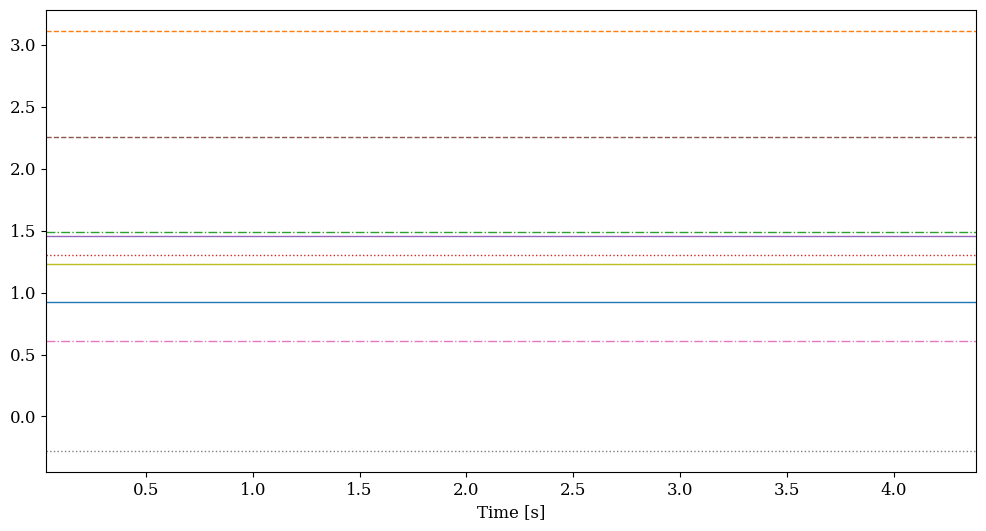

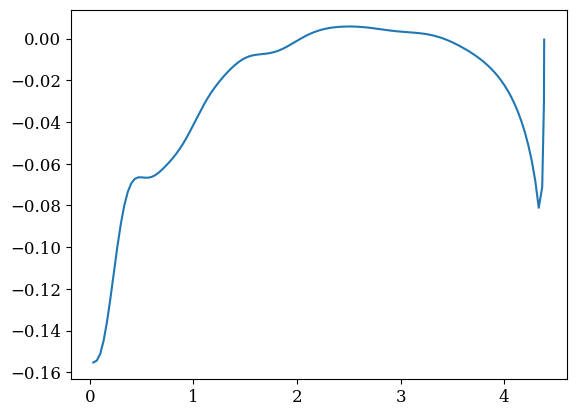

In [ ]:
ss.TDS.plotter.plot(ss.TDS.plotter.find("Pe REGCV1", idx_only=True), figsize=(12, 6))
ss.TDS.plotter.plot(ss.TDS.plotter.find("Pe GENROU", idx_only=True), figsize=(12, 6))
ss.TDS.plotter.plot(ss.TDS.plotter.find("omega COI", idx_only=True), ycalc=lambda x: x*50, figsize=(12, 6), )
# ss.TDS.plotter.plot(ss.TDS.plotter.find("omega COI", idx_only=True), ycalc=lambda x: np.gradient(x, edge_order=2), figsize=(12, 6), )
ss.TDS.plotter.plot(ss.TDS.plotter.find("delta COI", idx_only=True), figsize=(12, 6), )
ss.TDS.plotter.plot(ss.TDS.plotter.find("q PV", idx_only=True), figsize=(12, 6), )
freq = ss.TDS.plotter.get_values(ss.TDS.plotter.find("omega COI", idx_only=True))
rocof = np.gradient(freq, float(ss.TDS.config.tstep), axis=0) * 50
plt.plot(ss.TDS.plotter.get_values(0),rocof)

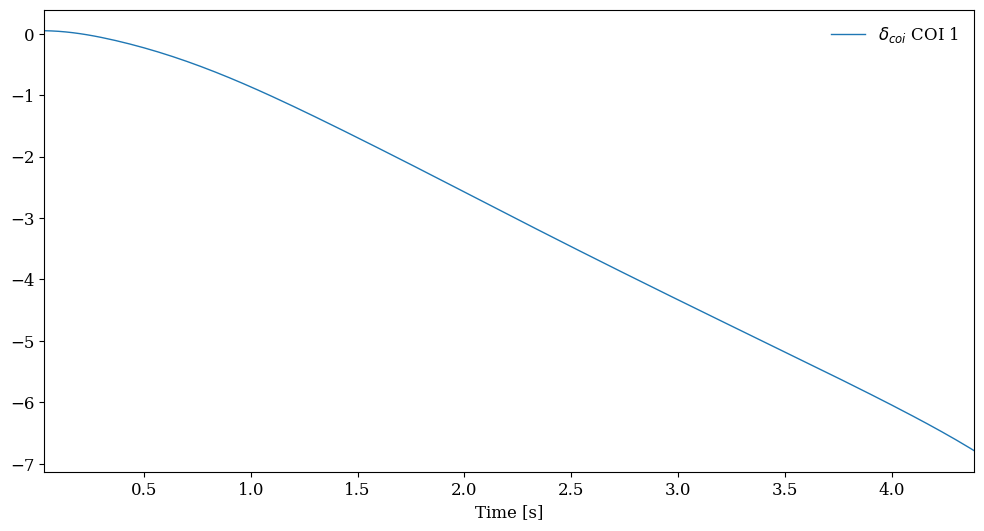

(<Figure size 1200x600 with 1 Axes>, <Axes: xlabel='Time [s]'>)

In [ ]:
ss.TDS.plotter.plot(ss.TDS.plotter.find("delta COI", idx_only=True), figsize=(12, 6))